## Student Dropout Prediction — Privacy Analysis
### MMA 609 | Responsible AI Project | Winter 2026

---
**A. OVERVIEW OF DATASET**

This project uses the **UCI Predict Students' Dropout and Academic Success** dataset, 
collected from a higher education institution in Portugal. The dataset contains 
information on 4,424 students across various undergraduate programs including 
agronomy, design, education, nursing, journalism, management, social service, 
and technology.

The dataset includes 35 features captured at the time of enrollment, covering:
- **Demographic information** (age, gender, Nacionality (dataset column name), marital status)
- **Socioeconomic background** (parental education, parental occupation)
- **Financial situation** (scholarship status, tuition payment, debtor status)
- **Academic performance** (admission grade, curricular units passed/failed)
- **Macroeconomic context** (unemployment rate, inflation rate, GDP)

The target variable consists of three categories: **Graduate**, **Dropout**, 
and **Enrolled**. For this project, we focus only on students with a known 
final outcome (Graduate or Dropout), removing students still enrolled.

**B. OBJECTIVE**

The objective of this project is to analyze the **privacy implications** of 
using an AI system to predict student dropout risk in a public school setting: 
> *"Does a student dropout prediction model actually need sensitive personal 
> data such as parental background, financial status, and demographic 
> information to accurately identify at-risk students — or can it perform 
> just as well using only academic performance data?"*

**C. TARGET VARIABLE & FEATURE CLASSIFICATION**
- Target Variable: Target

| Feature | Sensitivity | Justification |
|---------|------------|---------------|
| Marital status | High | Personal life information, purpose creep |
| Gender | High | Legally protected characteristic |
| Age at enrollment | High | Protected characteristic, identifiability risk |
| Nacionality (dataset column name) | High | Protected characteristic, discrimination risk |
| Displaced | High | Reveals personal living situation |
| International | High | Reveals immigration/residency status |
| Debtor | High | Reveals financial hardship, harm potential |
| Mother's qualification | High | Family background profiling, purpose creep |
| Father's qualification | High | Family background profiling, purpose creep |
| Mother's occupation | High | Family background profiling, purpose creep |
| Father's occupation | High | Family background profiling, purpose creep |
| Educational special needs | High | Disability status, legally protected |
| Scholarship holder | Moderate | Reveals financial need, lower harm risk |
| Tuition fees up to date | Moderate | Reveals financial situation |
| Application mode | Moderate | Reveals how student gained entry |
| Application order | Moderate | Reveals academic preference/priority |
| Previous qualification | Moderate | Reveals academic history |
| Previous qualification grade | Moderate | Reveals academic background |
| Admission grade | Moderate | Reveals academic entry level |
| Course | Moderate | Could reflect socioeconomic aspirations |
| Curricular units 1st sem (credited) | Low | Academic activity only |
| Curricular units 1st sem (enrolled) | Low | Academic activity only |
| Curricular units 1st sem (evaluations) | Low | Academic activity only |
| Curricular units 1st sem (approved) | Low | Academic activity only |
| Curricular units 1st sem (grade) | Low | Academic performance only |
| Curricular units 2nd sem (credited) | Low | Academic activity only |
| Curricular units 2nd sem (enrolled) | Low | Academic activity only |
| Curricular units 2nd sem (evaluations) | Low | Academic activity only |
| Curricular units 2nd sem (approved) | Low | Academic activity only |
| Curricular units 2nd sem (grade) | Low | Academic performance only |
| Daytime/evening attendance | Low | Schedule preference only |
| Unemployment rate | Low | External macroeconomic factor |
| Inflation rate | Low | External macroeconomic factor |
| GDP | Low | External macroeconomic factor |


## 1. Data Exploration

1.1 Import Libraries

### 1.1 Import Libraries

In [148]:
# Load necessary libraries
#%pip install numpy matplotlib pandas seaborn scikit-learn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# For model building and evaluation
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
#%pip install xgboost
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                             recall_score, confusion_matrix,
                             classification_report, roc_curve, auc)
from matplotlib.patches import Patch
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import learning_curve


1.2 Load Dataset

### 1.2 Load Dataset

In [149]:
df = pd.read_csv('dataset.csv')
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


1.3 Data Overview

### 1.3 Data Overview

In [150]:
# Checking for missing values and data types
print(df.isnull().sum())

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrollment                                 0
International                                     0
Curricular u

In [151]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                             4424

In [152]:
# summary statistics of the dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,6.886980,5.298964,1.00,1.00,8.000000,12.000000,18.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,9.899186,4.331792,1.00,6.00,10.000000,13.000000,17.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,2.531420,3.963707,1.00,1.00,1.000000,1.000000,17.000000
Nacionality,4424.0,1.254521,1.748447,1.00,1.00,1.000000,1.000000,21.000000
Mother's qualification,4424.0,12.322107,9.026251,1.00,2.00,13.000000,22.000000,29.000000
Father's qualification,4424.0,16.455244,11.044800,1.00,3.00,14.000000,27.000000,34.000000
Mother's occupation,4424.0,7.317812,3.997828,1.00,5.00,6.000000,10.000000,32.000000


In [153]:
# How many dropout vs graduate?
print(df['Target'].value_counts()) 

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [154]:
# Drop Enrolled students for binary classification
df = df[df['Target'] != 'Enrolled']

# Class balance check after dropping Enrolled
print("Class Distribution (Binary Dataset - After dropping Enrolled):")
print(df['Target'].value_counts())
print("\nClass Distribution (%):")
print(df['Target'].value_counts(normalize=True) * 100)
print("\nImbalance Ratio:")
counts = df['Target'].value_counts()
print(f"Dropout: {counts['Dropout']} ({counts['Dropout']/len(df)*100:.1f}%)")
print(f"Graduate: {counts['Graduate']} ({counts['Graduate']/len(df)*100:.1f}%)")
print(f"\nImbalance ratio: {counts.max() / counts.min():.2f}:1")

Class Distribution (Binary Dataset - After dropping Enrolled):
Target
Graduate    2209
Dropout     1421
Name: count, dtype: int64

Class Distribution (%):
Target
Graduate    60.853994
Dropout     39.146006
Name: proportion, dtype: float64

Imbalance Ratio:
Dropout: 1421 (39.1%)
Graduate: 2209 (60.9%)

Imbalance ratio: 1.55:1


### 1.4 Exploratory Analysis

In [155]:
# Configure plot style for academic reporting
sns.set(style="whitegrid", context="notebook")
# Ensure minus signs are displayed correctly
plt.rcParams['axes.unicode_minus'] = False 

C:\Users\Moggy Nguyen\AppData\Local\Temp\ipykernel_48876\3639411886.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Target', data=df, palette='viridis', order=df['Target'].value_counts().index)


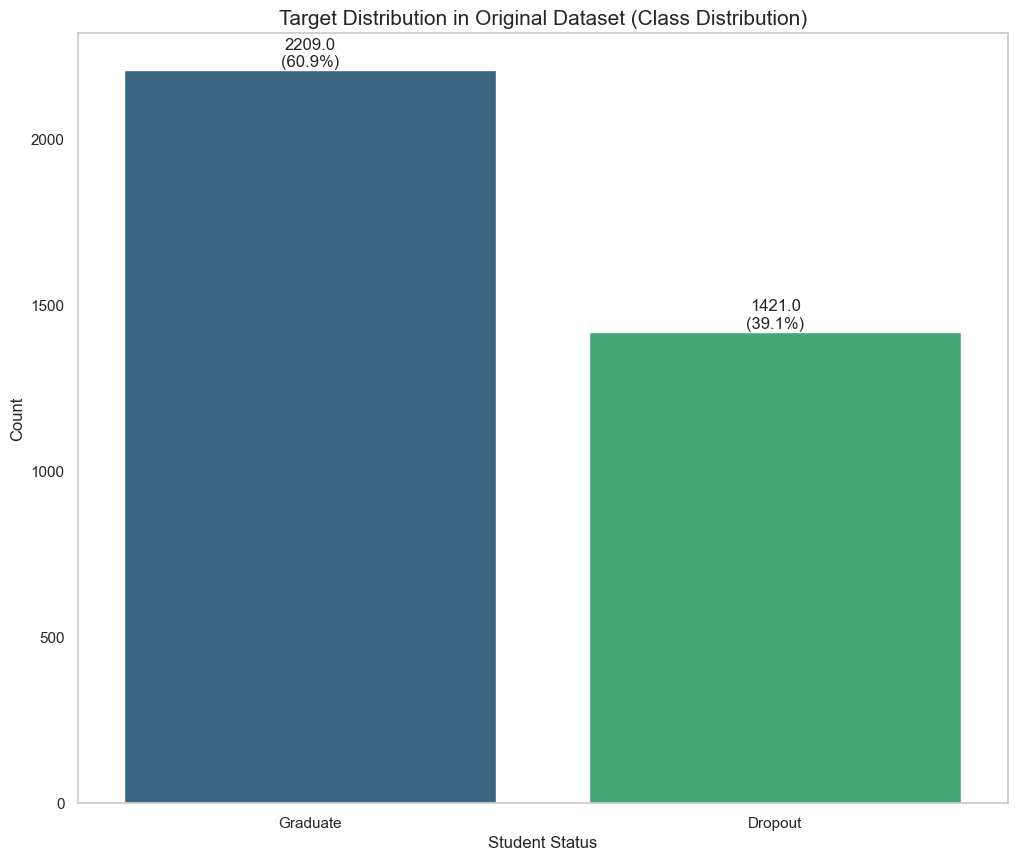

In [156]:
# Target Class Distribution
plt.figure(figsize=(12, 10))

# Plot count plot
ax = sns.countplot(x='Target', data=df, palette='viridis', order=df['Target'].value_counts().index)

# Add counts and percentages on the bars to enhance professional presentation
total = len(df)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(f'{y}\n({percentage})', (x, y), ha='center', va='bottom', fontsize=12)
# remove the grid lines for a cleaner look
ax.grid(False)

plt.title('Target Distribution in Original Dataset (Class Distribution)', fontsize=15)
plt.xlabel('Student Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

In [157]:
# Label mapping and helpers (Dropout = positive class)
label_map = {'Graduate': 0, 'Dropout': 1}
inv_label_map = {0: 'Graduate', 1: 'Dropout'}

def _to_str_labels(y):
    y_arr = np.asarray(y)
    if np.issubdtype(y_arr.dtype, np.number):
        return pd.Series(y_arr).map(inv_label_map).to_numpy()
    return y

def _y_to_num(y):
    y_arr = np.asarray(y)
    if np.issubdtype(y_arr.dtype, np.number):
        return y_arr
    return pd.Series(y_arr).map(label_map).to_numpy()

def _dropout_proba(model, X):
    proba = model.predict_proba(X)
    classes = list(model.classes_)
    if isinstance(classes[0], str):
        idx = classes.index('Dropout')
    else:
        idx = classes.index(label_map['Dropout'])
    return proba[:, idx]

In [158]:
# Feature sensitivity tiers (shared across sections)
# Grounded in GDPR Article 9, FERPA, NIST, and your notebook's Table C
tier1_high = {
    'Marital status', 'Gender', 'Age at enrollment', 'Nacionality',
    'Displaced', 'International', 'Debtor',
    "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation",
    'Educational special needs'
}

tier2_moderate = {
    'Scholarship holder', 'Tuition fees up to date',
    'Application mode', 'Application order',
    'Previous qualification', 'Course'
}

tier3_low = {
    'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)',
    'Daytime/evening attendance', 'Unemployment rate', 'Inflation rate', 'GDP'
}

def get_feature_tier(name):
    if name in tier1_high:
        return 'Tier 1 — High'
    if name in tier2_moderate:
        return 'Tier 2 — Moderate'
    return 'Tier 3 — Low'

tier_colors = {
    'Tier 1 — High':     '#d73027',   # red
    'Tier 2 — Moderate': '#fc8d59',   # orange
    'Tier 3 — Low':      '#1a9850'   # green
}

In [159]:
# number of features in each tier
tier_counts = {
    'Tier 1 — High': len(tier1_high),   
    'Tier 2 — Moderate': len(tier2_moderate),
    'Tier 3 — Low': len(tier3_low)
}
print("Feature Counts by Tier:")
for tier, count in tier_counts.items():
    print(f"{tier}: {count} features")  

Feature Counts by Tier:
Tier 1 — High: 12 features
Tier 2 — Moderate: 6 features
Tier 3 — Low: 16 features


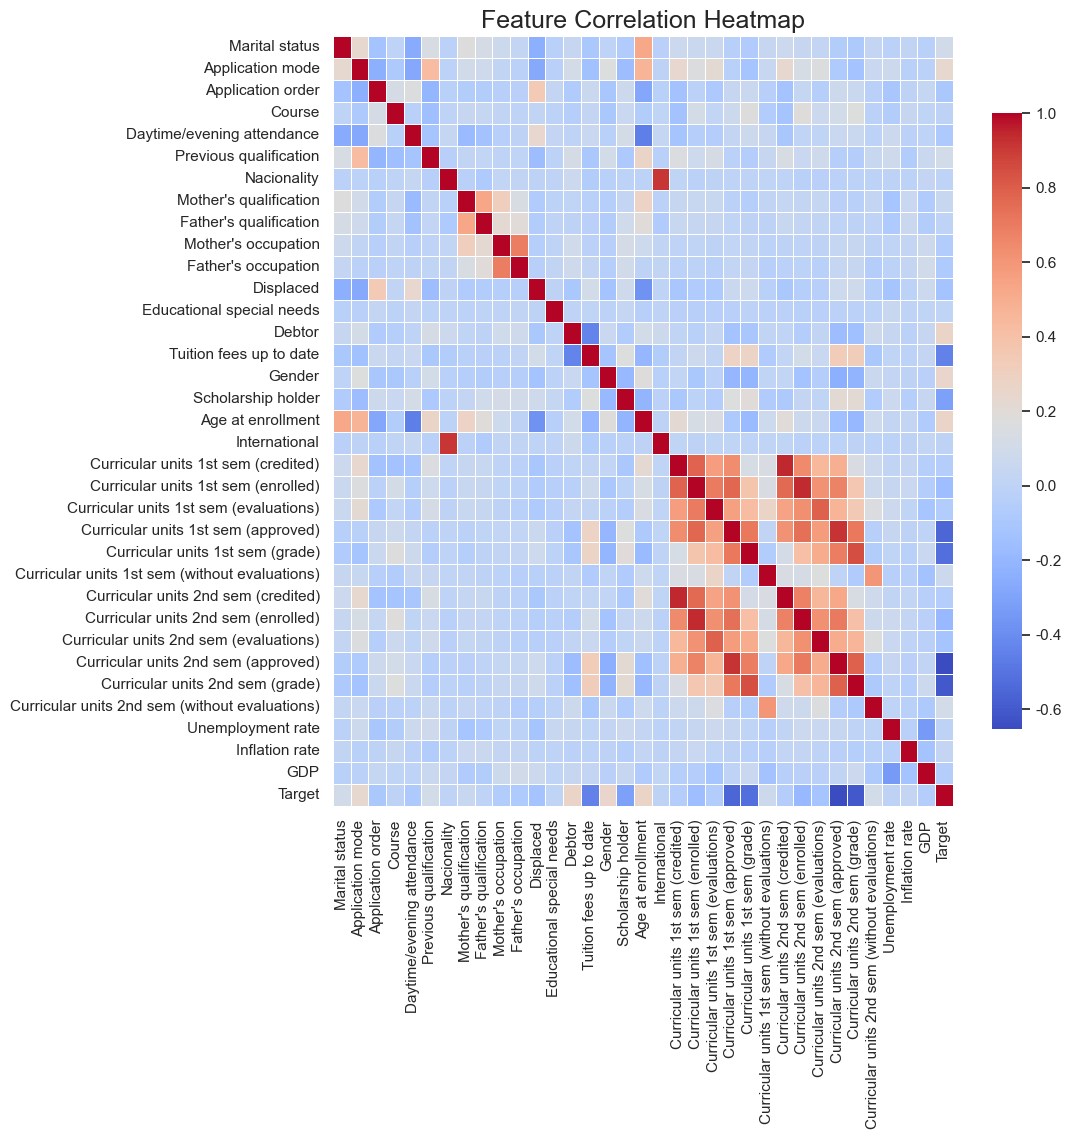

In [160]:
# Heatmap of correlations (Target encoded with label_map)
df_temp = df.copy()
df_temp['Target'] = df_temp['Target'].map(label_map)

# Calculate correlation matrix
plt.figure(figsize=(10, 10)) # Larger figure size for visibility of 30+ features
# numeric_only=True ensures compatibility with newer pandas versions
corr_matrix = df_temp.corr(numeric_only=True) 

# Plot heatmap
# annot=False: Hide numbers to avoid clutter due to small cell size
# cmap='coolwarm': Red indicates positive correlation, Blue indicates negative
sns.heatmap(corr_matrix, annot=False, fmt=".2f", cmap='coolwarm', 
            linewidths=0.5, cbar_kws={"shrink": .8})

plt.title('Feature Correlation Heatmap', fontsize=18)
plt.show()


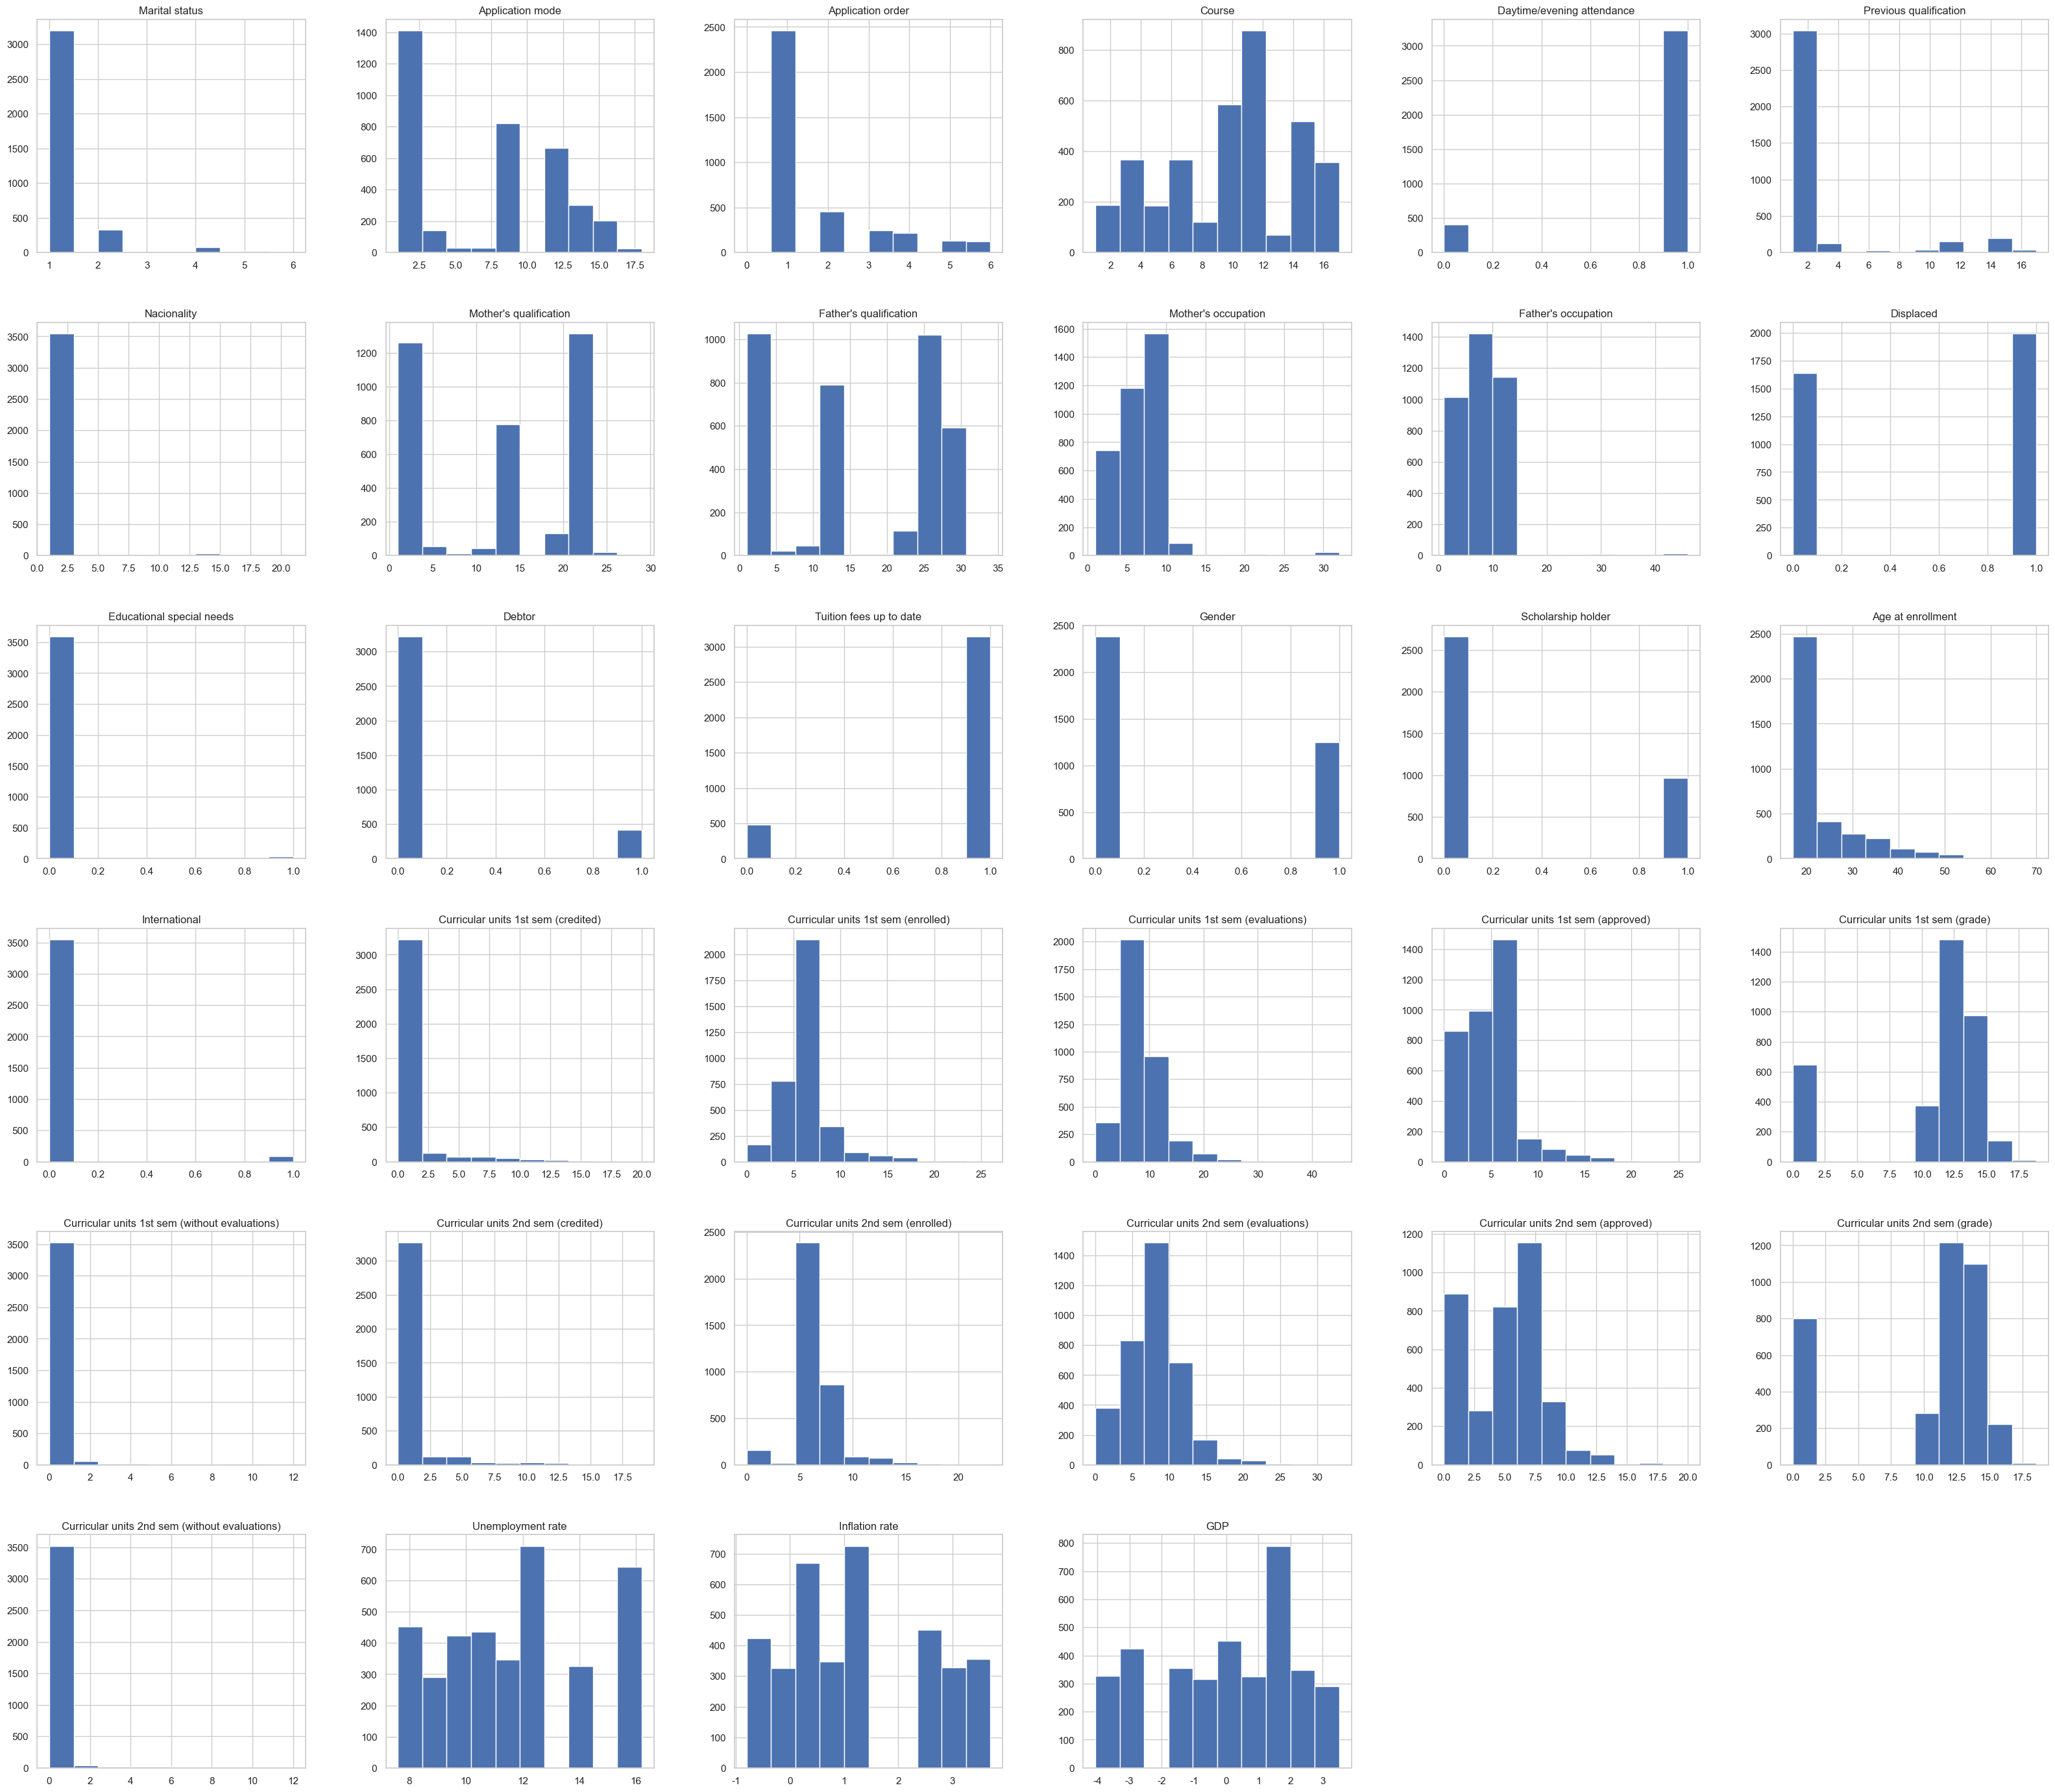

In [161]:
# Histograms of all features 
df.hist(bins=10, figsize=(40, 35), grid=True, legend=None);

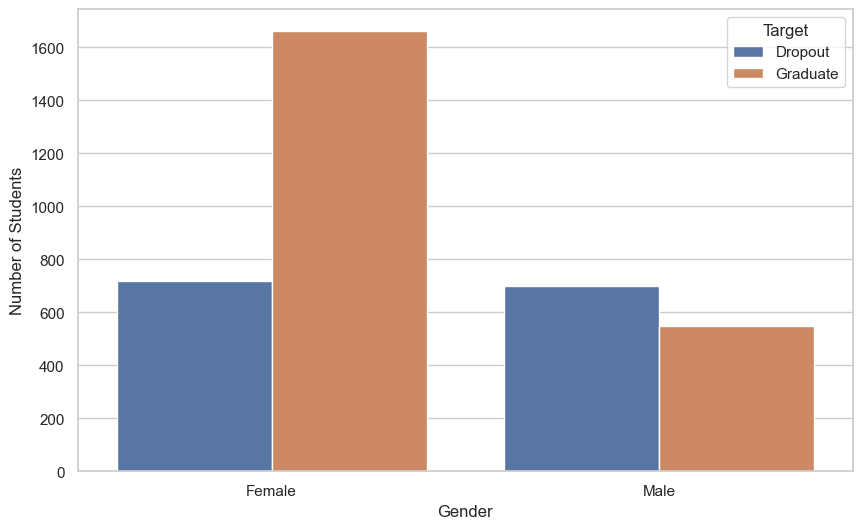

In [162]:
# Target variable by gender
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Gender', hue='Target', hue_order=['Dropout', 'Graduate'])
plt.xticks(ticks=[0,1], labels=['Female','Male'])
plt.ylabel('Number of Students')
plt.show()

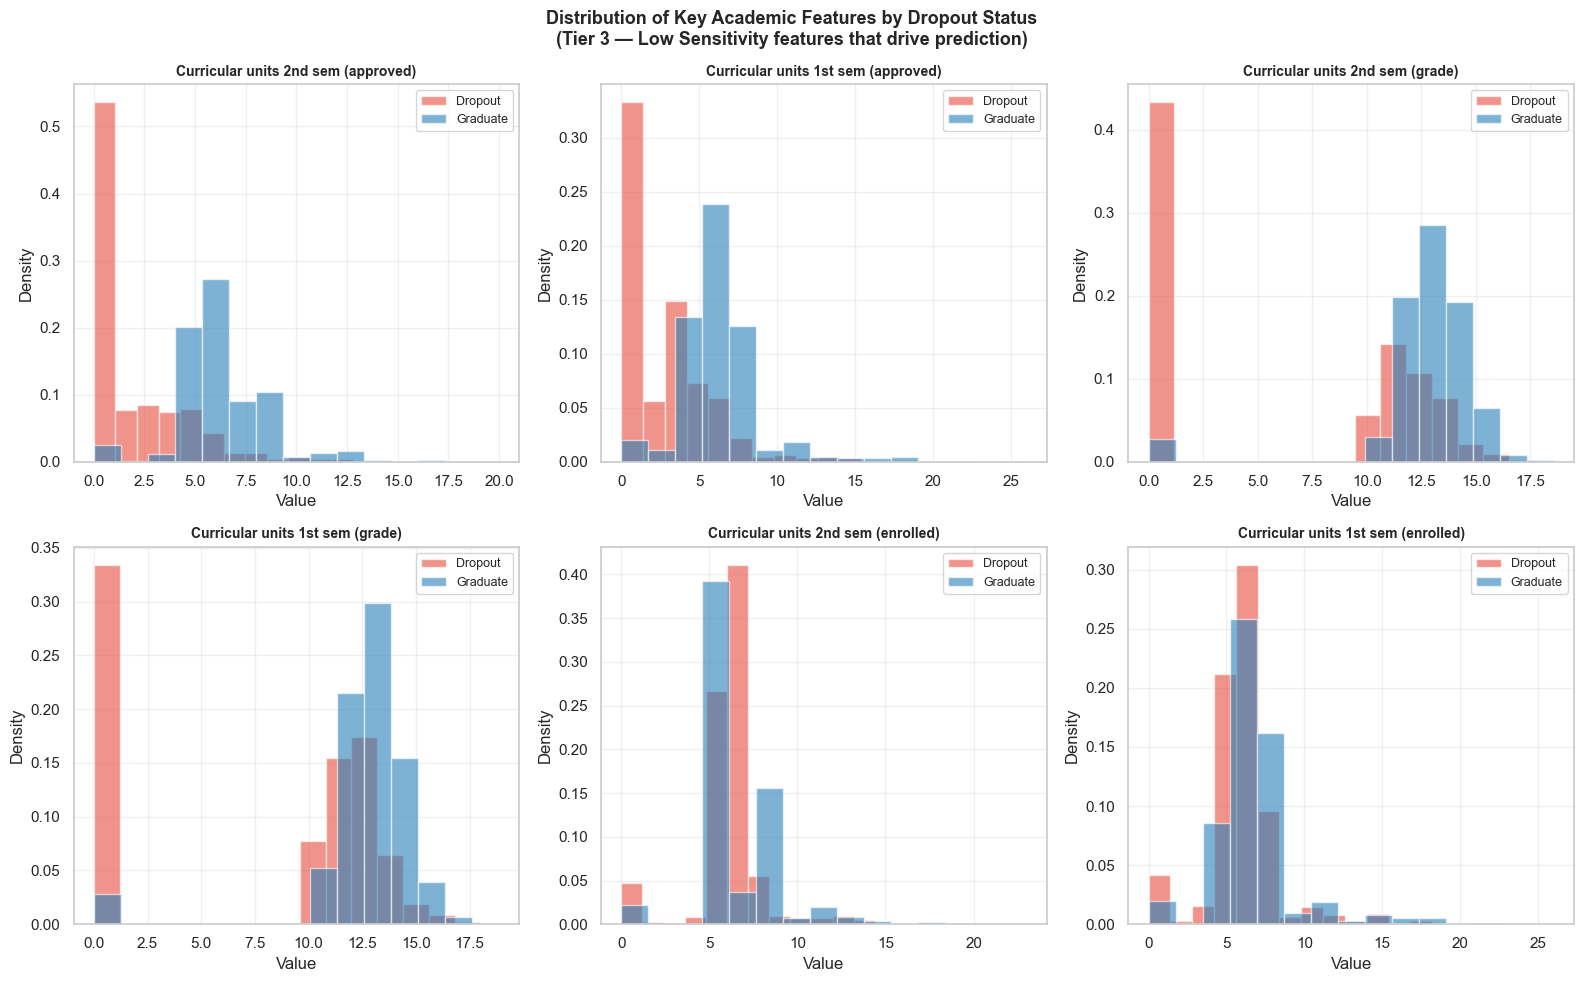

In [163]:
# Academic Feature Distributions vs Target

# Key Tier 3 features that showed highest correlation with target
academic_key = [
    'Curricular units 2nd sem (approved)',
    'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 1st sem (enrolled)',
]

# Filter to only those that exist in the dataframe
academic_key = [f for f in academic_key if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(academic_key):
    ax = axes[i]
    for label, color in [('Dropout', '#e74c3c'), ('Graduate', '#2980b9')]:
        subset = df[df['Target'] == label][feature]
        ax.hist(subset, bins=15, alpha=0.6, label=label,
                color=color, density=True, edgecolor='white')

    ax.set_title(feature, fontsize=10, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Hide any unused subplots
for j in range(len(academic_key), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Key Academic Features by Dropout Status\n'
             '(Tier 3 — Low Sensitivity features that drive prediction)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\Moggy Nguyen\AppData\Local\Temp\ipykernel_48876\78542473.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['Dropout', 'Graduate'],
C:\Users\Moggy Nguyen\AppData\Local\Temp\ipykernel_48876\78542473.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['Dropout', 'Graduate'],
C:\Users\Moggy Nguyen\AppData\Local\Temp\ipykernel_48876\78542473.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['Dropout', 'Graduate'],
C:\Users\Moggy Nguyen\AppData\Local\Temp\ipykernel_48876\78542473.py:26: MatplotlibDeprecationWarning: The

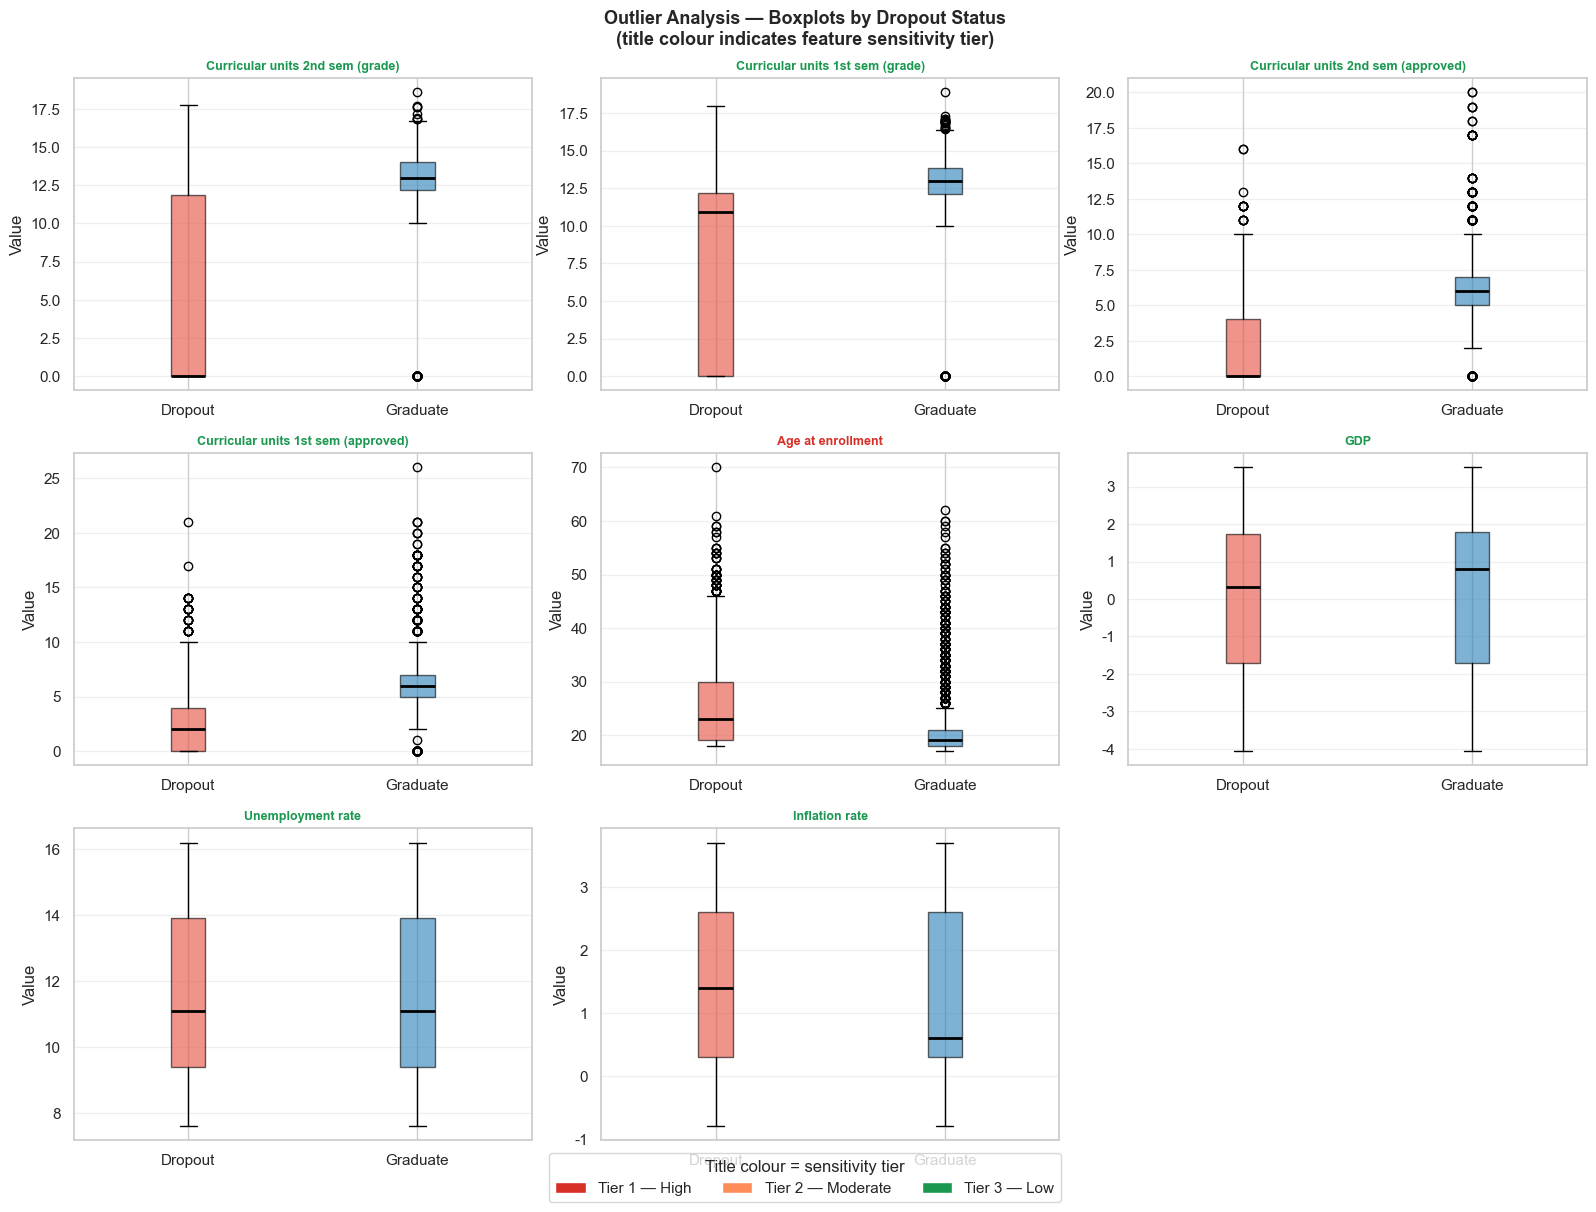

In [164]:
# Outlier Boxplot — Key continuous features
continuous_features = [
    'Curricular units 2nd sem (grade)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 1st sem (approved)',
    'Age at enrollment',
    'Admission grade',
    'GDP',
    'Unemployment rate',
    'Inflation rate',
]

# Filter to only those present in df
continuous_features = [f for f in continuous_features if f in df.columns]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(continuous_features):
    ax = axes[i]
    data = [
        df[df['Target'] == 'Dropout'][feature].dropna(),
        df[df['Target'] == 'Graduate'][feature].dropna(),
    ]
    bp = ax.boxplot(data, labels=['Dropout', 'Graduate'],
                    patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))

    bp['boxes'][0].set_facecolor('#e74c3c')
    bp['boxes'][1].set_facecolor('#2980b9')
    for patch in bp['boxes']:
        patch.set_alpha(0.6)

    # Colour-code title by tier
    tier  = get_feature_tier(feature)
    color = tier_colors.get(tier, '#7f7f7f')
    ax.set_title(feature, fontsize=9, fontweight='bold', color=color)
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3, axis='y')

for j in range(len(continuous_features), len(axes)):
    axes[j].set_visible(False)

# Legend for tier colours in titles
legend_handles = [
    Patch(facecolor=tier_colors['Tier 1 — High'],     label='Tier 1 — High'),
    Patch(facecolor=tier_colors['Tier 2 — Moderate'], label='Tier 2 — Moderate'),
    Patch(facecolor=tier_colors['Tier 3 — Low'],      label='Tier 3 — Low'),
]
fig.legend(handles=legend_handles, title='Title colour = sensitivity tier',
           loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Outlier Analysis — Boxplots by Dropout Status\n'
             '(title colour indicates feature sensitivity tier)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### 1.5 Correlation Analysis

In [165]:
# Full Correlation Analysis: Feature Groups and Ranking
# Copy data and ensure Target is numeric for correlation
df_corr = df.copy()
df_corr['Target'] = df_corr['Target'].map(label_map)

# Correlation with Target, ranked by absolute correlation
corr_with_target = df_corr.corr(numeric_only=True)['Target'].drop('Target').dropna()
corr_ranked = corr_with_target.reindex(
    corr_with_target.abs().sort_values(ascending=False).index
)

In [166]:
# ── Feature Sensitivity Classification (Three-Tier Framework) ─────
# Grounded in GDPR Article 9, FERPA, NIST, and your notebook's Table C

feature_tiers = corr_ranked.index.to_series().apply(get_feature_tier)

bar_colors = feature_tiers.map(tier_colors)

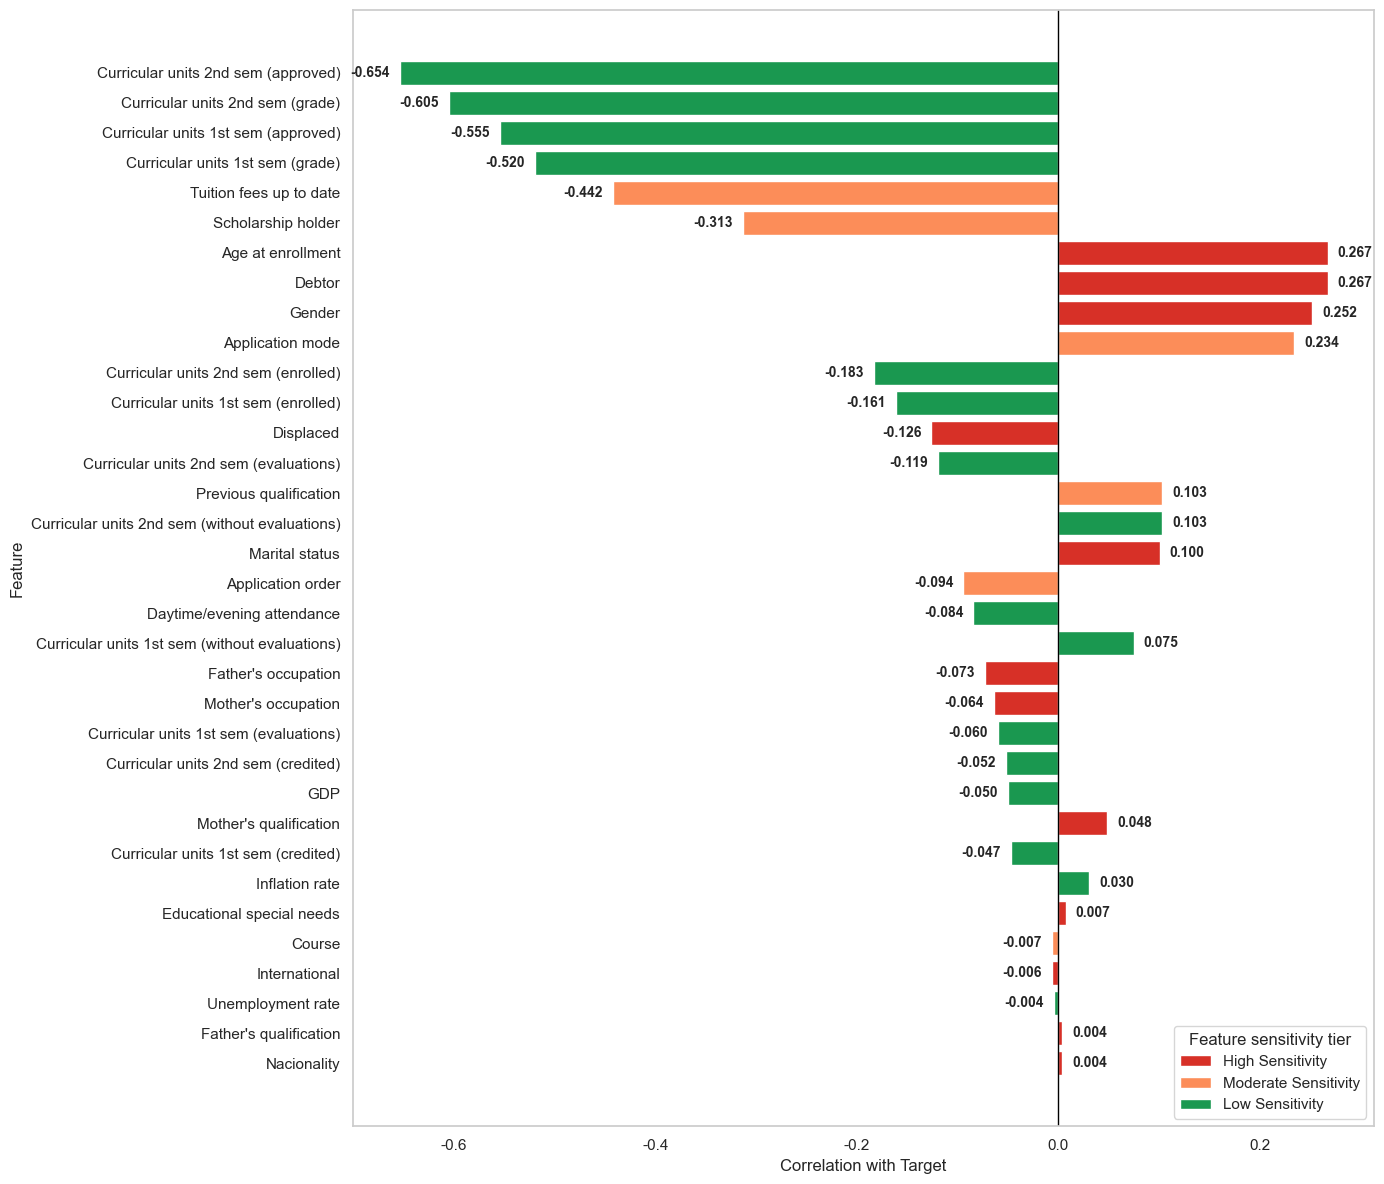

In [167]:
# Plot with numeric correlation labels
fig, ax = plt.subplots(figsize=(14, 12))
bars = ax.barh(corr_ranked.index, corr_ranked.values, color=bar_colors)
ax.axvline(0, color='black', linewidth=1)
ax.invert_yaxis()

# Add numeric labels on bars
for i, (feature, val) in enumerate(corr_ranked.items()):
    ax.text(val + 0.01 if val > 0 else val - 0.01, i, f'{val:.3f}', 
            ha='left' if val > 0 else 'right', va='center', fontsize=10, fontweight='bold')

legend_handles = [
    Patch(facecolor=tier_colors['Tier 1 — High'], label='High Sensitivity'),
    Patch(facecolor=tier_colors['Tier 2 — Moderate'], label='Moderate Sensitivity'),
    Patch(facecolor=tier_colors['Tier 3 — Low'], label='Low Sensitivity'),
]

ax.legend(handles=legend_handles, title='Feature sensitivity tier', loc='lower right')
ax.grid(False)

#ax.set_title('Feature Correlation with Target (Sorted by |Correlation|)', fontsize=14)
ax.set_xlabel('Correlation with Target', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
fig.tight_layout()
plt.show()

## 2. Building Models

2.1 Create Training and Testing Sets

### 2.1 Train / Test Split

In [168]:
# Define features and target
RANDOM_STATE = 2025 # Set random state for reproducibility
TEST_SIZE = 0.25 # Set test size for train-test split

# Separate features and target variable
X = df.drop(columns=['Target'])
y = df['Target']

# 75/25 split, stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE, 
    stratify=y         
)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print(f"Train dropout rate: {(y_train == 'Dropout').mean():.2%}")
print(f"Test dropout rate:  {(y_test == 'Dropout').mean():.2%}")

Train size: 2722 | Test size: 908
Train dropout rate: 39.16%
Test dropout rate:  39.10%


2.2 Build reusable preprocessing pipelines

### 2.2 Preprocessing Check

In [169]:
# Identify numerical and categorical columns
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns

print("Numerical columns:", numerical_cols.tolist())
print("Categorical columns:", categorical_cols.tolist()) 

Numerical columns: ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']
Categorical columns: []


> All columns are numeric, no categorical encoding needed

In [170]:
# Check for missing values in train and test sets
print("Missing values in training set:")
print(X_train.isnull().sum())
print("\nMissing values in test set:")
print(X_test.isnull().sum())


Missing values in training set:
Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrollment                                 0
International                   

> No missing values 

### 2.3 Helper Functions

In [171]:
# Reusable evaluation function for this notebook (Dropout vs Graduate)
def print_report(y_train, pred_train, y_test, pred_test, model_name='Model', labels=('Dropout', 'Graduate')):
    metrics = {}

    for split_name, y_true, y_pred in [
        ('Training', y_train, pred_train),
        ('Testing', y_test, pred_test),
    ]:
        acc = accuracy_score(y_true, y_pred)
        f1w = f1_score(y_true, y_pred, average='weighted')
        cm = confusion_matrix(y_true, y_pred, labels=list(labels))

        print(f'--- {model_name} | {split_name} Set ---')
        print(f'Accuracy: {acc:.4f}')
        print(f'Weighted F1: {f1w:.4f}')
        print('Confusion Matrix (rows=true, cols=pred):')
        print(pd.DataFrame(cm, index=[f'True {l}' for l in labels], columns=[f'Pred {l}' for l in labels]))
        print('Classification Report:')
        print(classification_report(y_true, y_pred, labels=list(labels), zero_division=0))
        print()

        metrics[split_name.lower()] = {'accuracy': acc, 'weighted_f1': f1w}

    return metrics

### 2.4 Model Training

> Each model runs twice — **Run 1** uses all 36 features, **Run 2** uses only Tier 3 low-sensitivity features.

#### 2.4.1 Logistic Regression

#### 2.4.1 Logistic Regression

In [172]:
# Logistic Regression — Pipeline and GridSearchCV

pipeline_lr = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

param_grid_lr = {
    'model__C':       [0.1, 1, 10],
    'model__penalty': ['l1', 'l2'],
    'model__solver':  ['liblinear']
}

grid_search_lr_run1 = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid_lr,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search_lr_run2 = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid_lr,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

In [173]:
# Fit — Run 1 (all features)
grid_search_lr_run1.fit(X_train, y_train)
best_lr = grid_search_lr_run1.best_estimator_
print(f'Best parameters for Logistic Regression: {grid_search_lr_run1.best_params_}')

pred_train_lr = best_lr.predict(X_train)
pred_test_lr  = best_lr.predict(X_test)
print_report(
    y_train, pred_train_lr, y_test, pred_test_lr,
    model_name='Logistic Regression — Run 1 (All Features)'
)

Best parameters for Logistic Regression: {'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
--- Logistic Regression — Run 1 (All Features) | Training Set ---
Accuracy: 0.9111
Weighted F1: 0.9109
Confusion Matrix (rows=true, cols=pred):
               Pred Dropout  Pred Graduate
True Dropout            932            134
True Graduate           108           1548
Classification Report:
              precision    recall  f1-score   support

     Dropout       0.90      0.87      0.89      1066
    Graduate       0.92      0.93      0.93      1656

    accuracy                           0.91      2722
   macro avg       0.91      0.90      0.91      2722
weighted avg       0.91      0.91      0.91      2722


--- Logistic Regression — Run 1 (All Features) | Testing Set ---
Accuracy: 0.9119
Weighted F1: 0.9119
Confusion Matrix (rows=true, cols=pred):
               Pred Dropout  Pred Graduate
True Dropout            316             39
True Graduate            41         

c:\Users\Moggy Nguyen\Downloads\MMA\Coding Python\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


{'training': {'accuracy': 0.9110947832476121,
  'weighted_f1': 0.9108922312148302},
 'testing': {'accuracy': 0.9118942731277533,
  'weighted_f1': 0.9119382112141475}}

In [174]:
# Fit — Run 2 (low-sensitivity features only)
# Build low-sensitivity feature subset from Tier 3 list
low_sensitivity_features = [c for c in X_train.columns if c in tier3_low]

print(f"Low-sensitivity features found: {len(low_sensitivity_features)}")
print(low_sensitivity_features)

X_train_low = X_train[low_sensitivity_features].copy()
X_test_low  = X_test[low_sensitivity_features].copy()

# y_train_enc is kept as an alias for clarity in Run 2 cells
y_train_enc = y_train.copy()
y_test_enc  = y_test.copy()

Low-sensitivity features found: 16
['Daytime/evening attendance', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']


In [175]:
grid_search_lr_run2.fit(X_train_low, y_train_enc)
best_lr2 = grid_search_lr_run2.best_estimator_
print(f'Best parameters for Logistic Regression (Run 2): {grid_search_lr_run2.best_params_}')

pred_train_lr2 = best_lr2.predict(X_train_low)
pred_test_lr2  = best_lr2.predict(X_test_low)
print_report(y_train_enc, pred_train_lr2, y_test_enc, pred_test_lr2,
             model_name='Logistic Regression — Run 2 (Low Sensitivity Only)')

Best parameters for Logistic Regression (Run 2): {'model__C': 0.1, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
--- Logistic Regression — Run 2 (Low Sensitivity Only) | Training Set ---
Accuracy: 0.8872
Weighted F1: 0.8871
Confusion Matrix (rows=true, cols=pred):
               Pred Dropout  Pred Graduate
True Dropout            907            159
True Graduate           148           1508
Classification Report:
              precision    recall  f1-score   support

     Dropout       0.86      0.85      0.86      1066
    Graduate       0.90      0.91      0.91      1656

    accuracy                           0.89      2722
   macro avg       0.88      0.88      0.88      2722
weighted avg       0.89      0.89      0.89      2722


--- Logistic Regression — Run 2 (Low Sensitivity Only) | Testing Set ---
Accuracy: 0.8899
Weighted F1: 0.8896
Confusion Matrix (rows=true, cols=pred):
               Pred Dropout  Pred Graduate
True Dropout            301             54
True Gradu

c:\Users\Moggy Nguyen\Downloads\MMA\Coding Python\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Moggy Nguyen\Downloads\MMA\Coding Python\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


{'training': {'accuracy': 0.8872152828802351,
  'weighted_f1': 0.8871094924454632},
 'testing': {'accuracy': 0.8898678414096917, 'weighted_f1': 0.889635755349657}}

#### 2.4.2 Random Forest

In [176]:
# Random Forest — Pipeline and GridSearchCV

pipeline_rf = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

param_grid_rf = {
    'model__n_estimators':     [100, 200],
    'model__max_depth':        [None, 6, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

grid_search_rf_run1 = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search_rf_run2 = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

In [177]:
# Fit — Run 1
grid_search_rf_run1.fit(X_train, y_train)
best_rf = grid_search_rf_run1.best_estimator_
print(f'Best parameters for Random Forest: {grid_search_rf_run1.best_params_}')

pred_train_rf = best_rf.predict(X_train)
pred_test_rf  = best_rf.predict(X_test)
print_report(y_train, pred_train_rf, y_test, pred_test_rf,
             model_name='Random Forest — Run 1 (All Features)')

Best parameters for Random Forest: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__n_estimators': 100}
--- Random Forest — Run 1 (All Features) | Training Set ---
Accuracy: 0.9813
Weighted F1: 0.9812
Confusion Matrix (rows=true, cols=pred):
               Pred Dropout  Pred Graduate
True Dropout           1026             40
True Graduate            11           1645
Classification Report:
              precision    recall  f1-score   support

     Dropout       0.99      0.96      0.98      1066
    Graduate       0.98      0.99      0.98      1656

    accuracy                           0.98      2722
   macro avg       0.98      0.98      0.98      2722
weighted avg       0.98      0.98      0.98      2722


--- Random Forest — Run 1 (All Features) | Testing Set ---
Accuracy: 0.9053
Weighted F1: 0.9046
Confusion Matrix (rows=true, cols=pred):
               Pred Dropout  Pred Graduate
True Dropout            299             56
True Graduate            30            

{'training': {'accuracy': 0.9812637766348273,
  'weighted_f1': 0.9812159075688249},
 'testing': {'accuracy': 0.9052863436123348, 'weighted_f1': 0.904573931260856}}

In [178]:
# Fit — Run 2
grid_search_rf_run2.fit(X_train_low, y_train_enc)
best_rf2 = grid_search_rf_run2.best_estimator_
print(f'Best parameters for Random Forest (Run 2): {grid_search_rf_run2.best_params_}')

pred_train_rf2 = best_rf2.predict(X_train_low)
pred_test_rf2  = best_rf2.predict(X_test_low)
print_report(y_train_enc, pred_train_rf2, y_test_enc, pred_test_rf2,
             model_name='Random Forest — Run 2 (Low Sensitivity Only)')

Best parameters for Random Forest (Run 2): {'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__n_estimators': 100}
--- Random Forest — Run 2 (Low Sensitivity Only) | Training Set ---
Accuracy: 0.9229
Weighted F1: 0.9224
Confusion Matrix (rows=true, cols=pred):
               Pred Dropout  Pred Graduate
True Dropout            927            139
True Graduate            71           1585
Classification Report:
              precision    recall  f1-score   support

     Dropout       0.93      0.87      0.90      1066
    Graduate       0.92      0.96      0.94      1656

    accuracy                           0.92      2722
   macro avg       0.92      0.91      0.92      2722
weighted avg       0.92      0.92      0.92      2722


--- Random Forest — Run 2 (Low Sensitivity Only) | Testing Set ---
Accuracy: 0.8822
Weighted F1: 0.8815
Confusion Matrix (rows=true, cols=pred):
               Pred Dropout  Pred Graduate
True Dropout            291             64
True Graduate    

{'training': {'accuracy': 0.922850844966936,
  'weighted_f1': 0.9223560336921093},
 'testing': {'accuracy': 0.8821585903083701,
  'weighted_f1': 0.8814606501289093}}

#### 2.4.3 XGBoost

In [179]:
# XGBoost — Pipeline and GridSearchCV
# scale_pos_weight: Graduate(negative) / Dropout(positive) — upweights Dropout (label=1)
scale_pos_weight = (y_train == 'Graduate').sum() / (y_train == 'Dropout').sum()

pipeline_xgb = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        tree_method='hist',
        eval_metric='logloss',
        random_state=RANDOM_STATE
    ))
])

param_grid_xgb = {
    'model__n_estimators':  [50, 100, 150],
    'model__max_depth':     [3, 5, 7],
    'model__learning_rate': [0.01, 0.1, 0.2]
}

grid_search_xgb_run1 = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search_xgb_run2 = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

In [180]:
# Fit — Run 1 (with encoded target)
print(f'XGB label mapping: {label_map}')

y_train_encoded = y_train.map(label_map).to_numpy()
y_test_encoded  = y_test.map(label_map).to_numpy()

grid_search_xgb_run1.fit(X_train, y_train_encoded)
best_xgb = grid_search_xgb_run1.best_estimator_
print(f'Best parameters for XGBoost: {grid_search_xgb_run1.best_params_}')

pred_train_xgb = best_xgb.predict(X_train)
pred_test_xgb  = best_xgb.predict(X_test)

# Decode predictions back to original labels for reporting
pred_train_xgb_labels = pd.Series(pred_train_xgb).map(inv_label_map).to_numpy()
pred_test_xgb_labels = pd.Series(pred_test_xgb).map(inv_label_map).to_numpy()

print_report(y_train, pred_train_xgb_labels, y_test, pred_test_xgb_labels,
             model_name='XGBoost — Run 1 (All Features)')

XGB label mapping: {'Graduate': 0, 'Dropout': 1}
Best parameters for XGBoost: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 150}
--- XGBoost — Run 1 (All Features) | Training Set ---
Accuracy: 0.9467
Weighted F1: 0.9465
Confusion Matrix (rows=true, cols=pred):
               Pred Dropout  Pred Graduate
True Dropout            968             98
True Graduate            47           1609
Classification Report:
              precision    recall  f1-score   support

     Dropout       0.95      0.91      0.93      1066
    Graduate       0.94      0.97      0.96      1656

    accuracy                           0.95      2722
   macro avg       0.95      0.94      0.94      2722
weighted avg       0.95      0.95      0.95      2722


--- XGBoost — Run 1 (All Features) | Testing Set ---
Accuracy: 0.9097
Weighted F1: 0.9094
Confusion Matrix (rows=true, cols=pred):
               Pred Dropout  Pred Graduate
True Dropout            308             47
True Graduat

{'training': {'accuracy': 0.946730345334313, 'weighted_f1': 0.94648151166745},
 'testing': {'accuracy': 0.9096916299559471,
  'weighted_f1': 0.9094000005464524}}

In [181]:
# Fit — Run 2 (with encoded target for low-sensitivity features)
y_train_enc_encoded = y_train_enc.map(label_map).to_numpy()
y_test_enc_encoded  = y_test_enc.map(label_map).to_numpy()

grid_search_xgb_run2.fit(X_train_low, y_train_enc_encoded)
best_xgb2 = grid_search_xgb_run2.best_estimator_
print(f'Best parameters for XGBoost (Run 2): {grid_search_xgb_run2.best_params_}')

pred_train_xgb2 = best_xgb2.predict(X_train_low)
pred_test_xgb2  = best_xgb2.predict(X_test_low)

# Decode predictions back to original labels
pred_train_xgb2_labels = pd.Series(pred_train_xgb2).map(inv_label_map).to_numpy()
pred_test_xgb2_labels = pd.Series(pred_test_xgb2).map(inv_label_map).to_numpy()

print_report(y_train_enc, pred_train_xgb2_labels, y_test_enc, pred_test_xgb2_labels,
             model_name='XGBoost — Run 2 (Low Sensitivity Only)')

Best parameters for XGBoost (Run 2): {'model__learning_rate': 0.2, 'model__max_depth': 3, 'model__n_estimators': 100}
--- XGBoost — Run 2 (Low Sensitivity Only) | Training Set ---
Accuracy: 0.9203
Weighted F1: 0.9201
Confusion Matrix (rows=true, cols=pred):
               Pred Dropout  Pred Graduate
True Dropout            948            118
True Graduate            99           1557
Classification Report:
              precision    recall  f1-score   support

     Dropout       0.91      0.89      0.90      1066
    Graduate       0.93      0.94      0.93      1656

    accuracy                           0.92      2722
   macro avg       0.92      0.91      0.92      2722
weighted avg       0.92      0.92      0.92      2722


--- XGBoost — Run 2 (Low Sensitivity Only) | Testing Set ---
Accuracy: 0.8811
Weighted F1: 0.8811
Confusion Matrix (rows=true, cols=pred):
               Pred Dropout  Pred Graduate
True Dropout            301             54
True Graduate            54          

{'training': {'accuracy': 0.9202792064658339,
  'weighted_f1': 0.9201481470050465},
 'testing': {'accuracy': 0.8810572687224669,
  'weighted_f1': 0.8810572687224669}}

## 3. Evaluation

### 3.1 Model Performance Comparison

In [182]:
# Model Selection and Performance Comparison
models_run1 = {
    'Logistic Regression': best_lr,
    'Random Forest':       best_rf,
    'XGBoost':             best_xgb
}

models_run2 = {
    'Logistic Regression': best_lr2,
    'Random Forest':       best_rf2,
    'XGBoost':             best_xgb2
}

results_list = []

for run_name, (models, X_te, y_te) in {
    'Run 1 — All Features':    (models_run1, X_test, y_test),
    'Run 2 — Low Sensitivity': (models_run2, X_test_low, y_test_enc)
}.items():
    for model_name, model in models.items():
        y_pred = model.predict(X_te)
        y_pred_str = _to_str_labels(y_pred)
        y_te_str = _to_str_labels(y_te)
        y_te_num = (pd.Series(y_te_str) == 'Dropout').astype(int).to_numpy()
        y_pred_prob = _dropout_proba(model, X_te)
        results_list.append({
            'Run':       run_name,
            'Model':     model_name,
            'Accuracy':  accuracy_score(y_te_str, y_pred_str),
            'AUC':       roc_auc_score(y_te_num, y_pred_prob),
            'F1':        f1_score(y_te_str, y_pred_str, average='weighted'),
            'Recall':    recall_score(y_te_str, y_pred_str, average='weighted')
        })

comparison_df = pd.DataFrame(results_list).sort_values(
    ['Run', 'AUC'], ascending=[True, False]
).reset_index(drop=True)

print("--- Model Performance Comparison ---")
display(comparison_df)

--- Model Performance Comparison ---


,Run,Model,Accuracy,AUC,F1,Recall
0,Run 1 — All Features,Logistic Regression,0.911894,0.957278,0.911938,0.911894
1,Run 1 — All Features,Random Forest,0.905286,0.954614,0.904574,0.905286
2,Run 1 — All Features,XGBoost,0.909692,0.952092,0.909400,0.909692
3,Run 2 — Low Sensitivity,Logistic Regression,0.889868,0.939854,0.889636,0.889868
4,Run 2 — Low Sensitivity,Random Forest,0.882159,0.937274,0.881461,0.882159
5,Run 2 — Low Sensitivity,XGBoost,0.881057,0.934819,0.881057,0.881057


### 3.2 Train vs Test Accuracy

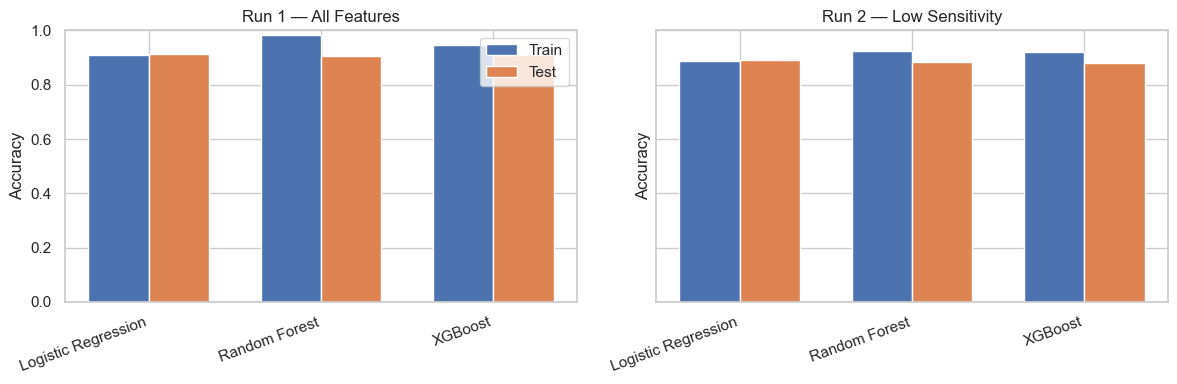

In [183]:
# Two separate graphs side-by-side (Run 1 vs Run 2)
def _acc_table(models, X_tr, y_tr, X_te, y_te):
    rows = []
    for model_name, model in models.items():
        y_tr_pred = model.predict(X_tr)
        y_te_pred = model.predict(X_te)
        y_tr_str = _to_str_labels(y_tr)
        y_te_str = _to_str_labels(y_te)
        y_tr_pred_str = _to_str_labels(y_tr_pred)
        y_te_pred_str = _to_str_labels(y_te_pred)

        rows.append({
            "Model": model_name,
            "Train Accuracy": accuracy_score(y_tr_str, y_tr_pred_str),
            "Test Accuracy":  accuracy_score(y_te_str, y_te_pred_str),
        })
    return pd.DataFrame(rows)

acc_run1 = _acc_table(models_run1, X_train, y_train, X_test, y_test)
acc_run2 = _acc_table(models_run2, X_train_low, y_train_enc, X_test_low, y_test_enc)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, acc_df, title in [
    (axes[0], acc_run1, "Run 1 — All Features"),
    (axes[1], acc_run2, "Run 2 — Low Sensitivity"),
]:
    x = np.arange(len(acc_df))
    width = 0.35
    ax.bar(x - width/2, acc_df["Train Accuracy"], width, label="Train")
    ax.bar(x + width/2, acc_df["Test Accuracy"],  width, label="Test")
    ax.set_xticks(x)
    ax.set_xticklabels(acc_df["Model"], rotation=20, ha="right")
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.set_ylabel("Accuracy")

axes[0].legend()
plt.tight_layout()
plt.show()

### 3.3 Learning Curves

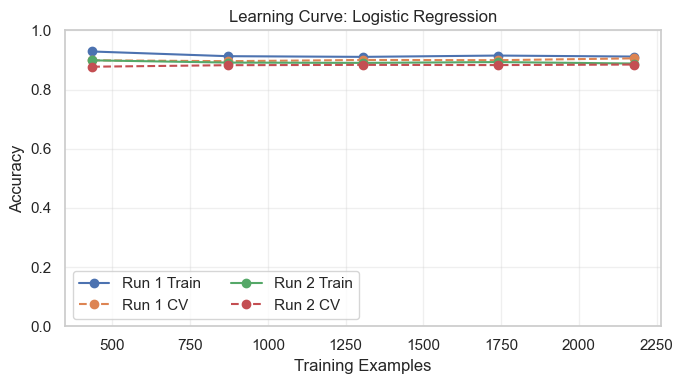

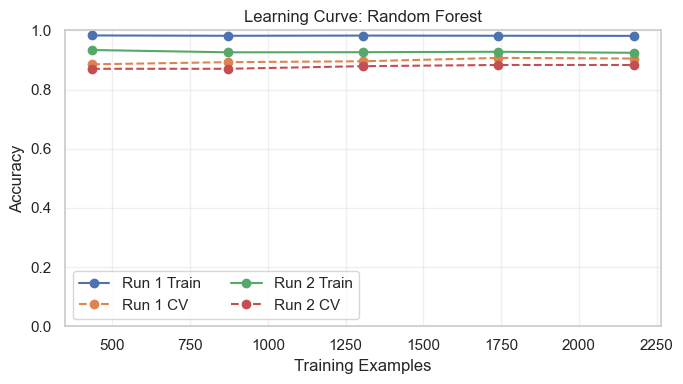

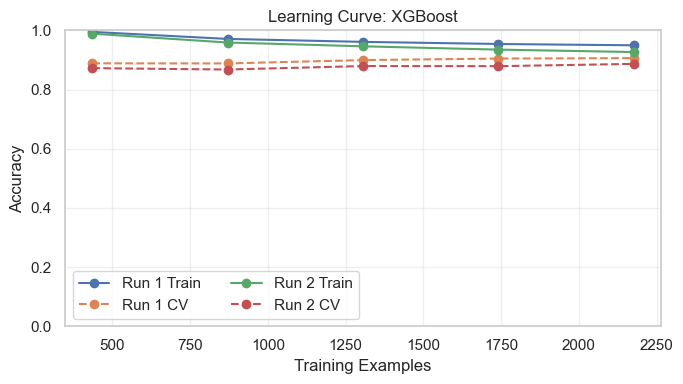

In [184]:
# Learning curves: three separate graphs (one per model)
# Each graph compares Run 1 vs Run 2

def _lc_data(model, X_tr, y_tr, is_xgb):
    train_sizes = np.linspace(0.2, 1.0, 5)
    y_used = y_tr.map(label_map).to_numpy() if is_xgb else y_tr
    sizes, train_scores, valid_scores = learning_curve(
        model, X_tr, y_used, train_sizes=train_sizes, cv=5, scoring="accuracy", n_jobs=-1
    )
    return sizes, train_scores.mean(axis=1), valid_scores.mean(axis=1)

def _plot_model_curves(model_name):
    model_run1 = models_run1[model_name]
    model_run2 = models_run2[model_name]
    is_xgb = "XGBoost" in model_name

    s1, tr1, cv1 = _lc_data(model_run1, X_train, y_train, is_xgb)
    s2, tr2, cv2 = _lc_data(model_run2, X_train_low, y_train_enc, is_xgb)

    plt.figure(figsize=(7, 4))
    plt.plot(s1, tr1, marker="o", label="Run 1 Train")
    plt.plot(s1, cv1, marker="o", linestyle="--", label="Run 1 CV")
    plt.plot(s2, tr2, marker="o", label="Run 2 Train")
    plt.plot(s2, cv2, marker="o", linestyle="--", label="Run 2 CV")
    plt.title(f"Learning Curve: {model_name}")
    plt.xlabel("Training Examples")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

for name in ["Logistic Regression", "Random Forest", "XGBoost"]:
    _plot_model_curves(name)

### 3.4 Overfitting Analysis

In [185]:
# Overfitting table (Run 1 and Run 2)
def _overfit_table(acc_df, run_label):
    df_out = acc_df.copy()
    df_out["Overfit Gap (Train - Test)"] = df_out["Train Accuracy"] - df_out["Test Accuracy"]
    df_out.insert(0, "Run", run_label)
    return df_out[["Run", "Model", "Train Accuracy", "Test Accuracy", "Overfit Gap (Train - Test)"]]

overfit_run1 = _overfit_table(acc_run1, "Run 1 — All Features")
overfit_run2 = _overfit_table(acc_run2, "Run 2 — Low Sensitivity")
overfit_table = pd.concat([overfit_run1, overfit_run2], ignore_index=True)

display(overfit_table)

,Run,Model,Train Accuracy,Test Accuracy,Overfit Gap (Train - Test)
0,Run 1 — All Features,Logistic Regression,0.911095,0.911894,-0.000799
1,Run 1 — All Features,Random Forest,0.981264,0.905286,0.075977
2,Run 1 — All Features,XGBoost,0.946730,0.909692,0.037039
3,Run 2 — Low Sensitivity,Logistic Regression,0.887215,0.889868,-0.002653
4,Run 2 — Low Sensitivity,Random Forest,0.922851,0.882159,0.040692
5,Run 2 — Low Sensitivity,XGBoost,0.920279,0.881057,0.039222


### 3.5 ROC Curve

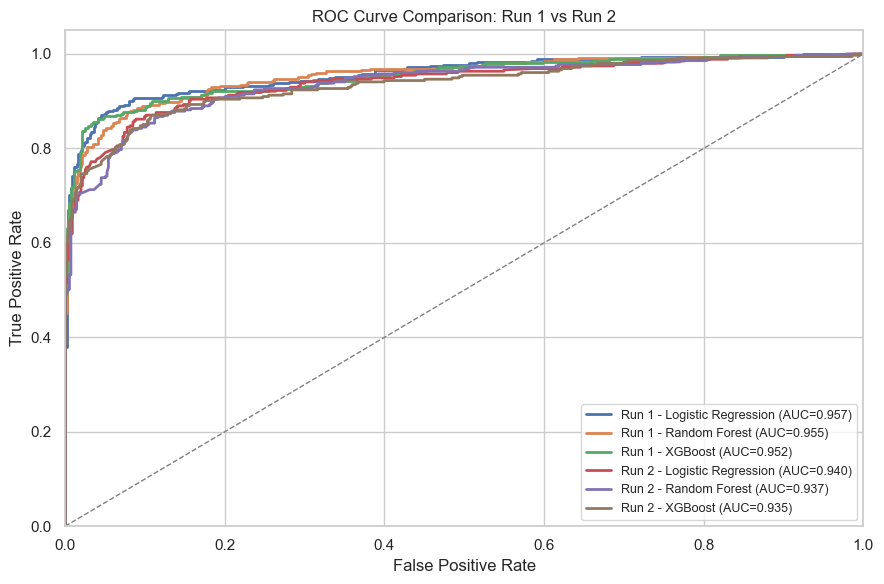

In [186]:
# ROC Curve comparison: all 6 model/run combinations
roc_sets = [
    ("Run 1 - Logistic Regression", models_run1['Logistic Regression'], X_test, y_test),
    ("Run 1 - Random Forest",       models_run1['Random Forest'],       X_test, y_test),
    ("Run 1 - XGBoost",             models_run1['XGBoost'],             X_test, y_test),
    ("Run 2 - Logistic Regression", models_run2['Logistic Regression'], X_test_low, y_test_enc),
    ("Run 2 - Random Forest",       models_run2['Random Forest'],       X_test_low, y_test_enc),
    ("Run 2 - XGBoost",             models_run2['XGBoost'],             X_test_low, y_test_enc),
]

plt.figure(figsize=(9, 6))
for label, model, X_te, y_te in roc_sets:
    y_true = _y_to_num(y_te)
    y_score = _dropout_proba(model, X_te)
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f"{label} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Run 1 vs Run 2')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

### 3.6 Feature Importance

> Logistic Regression is used as it achieved the highest AUC in both Run 1 and Run 2, outperforming Random Forest and XGBoost.

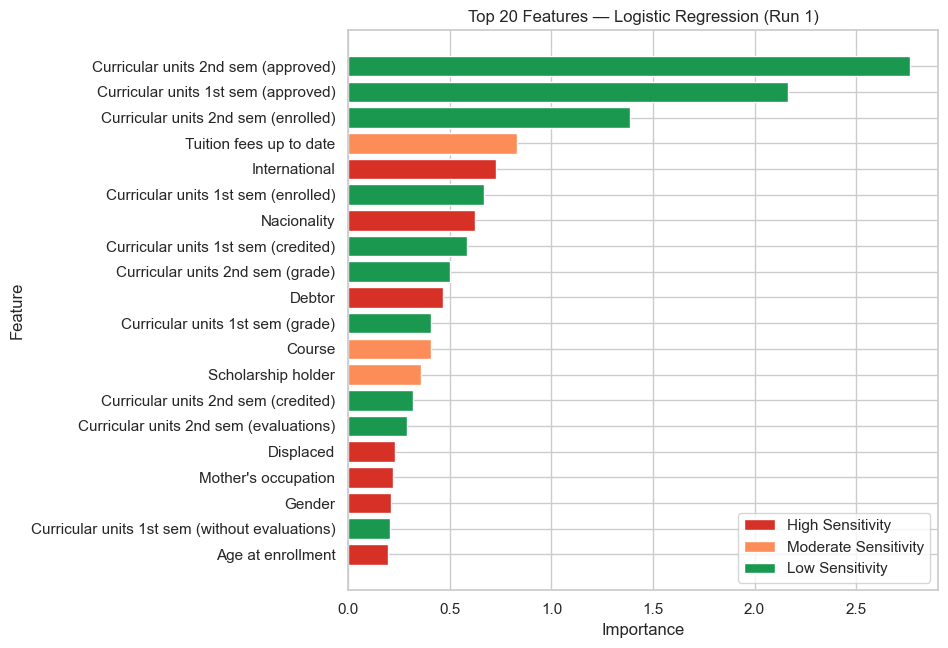

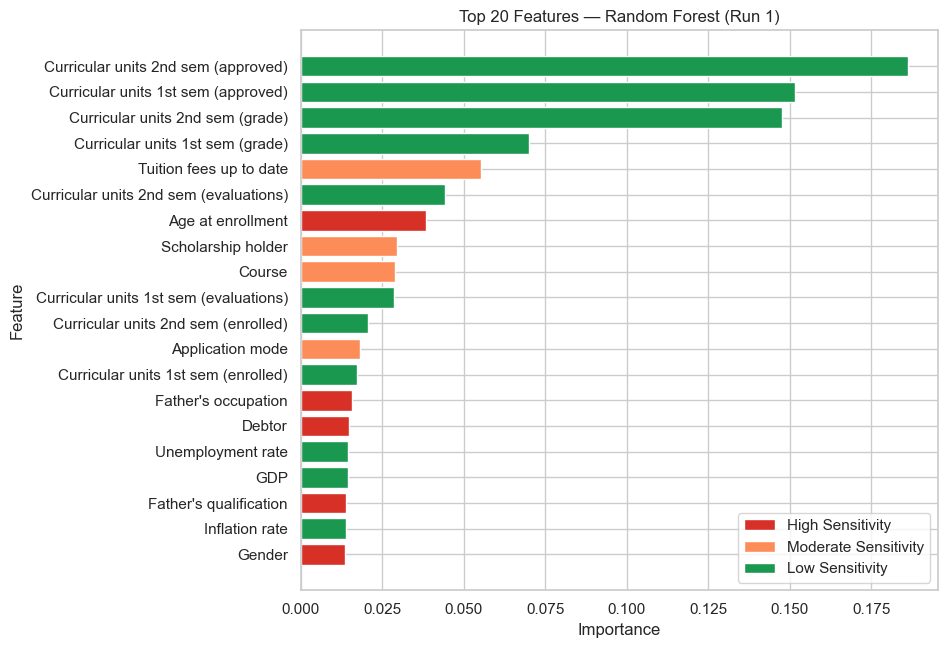

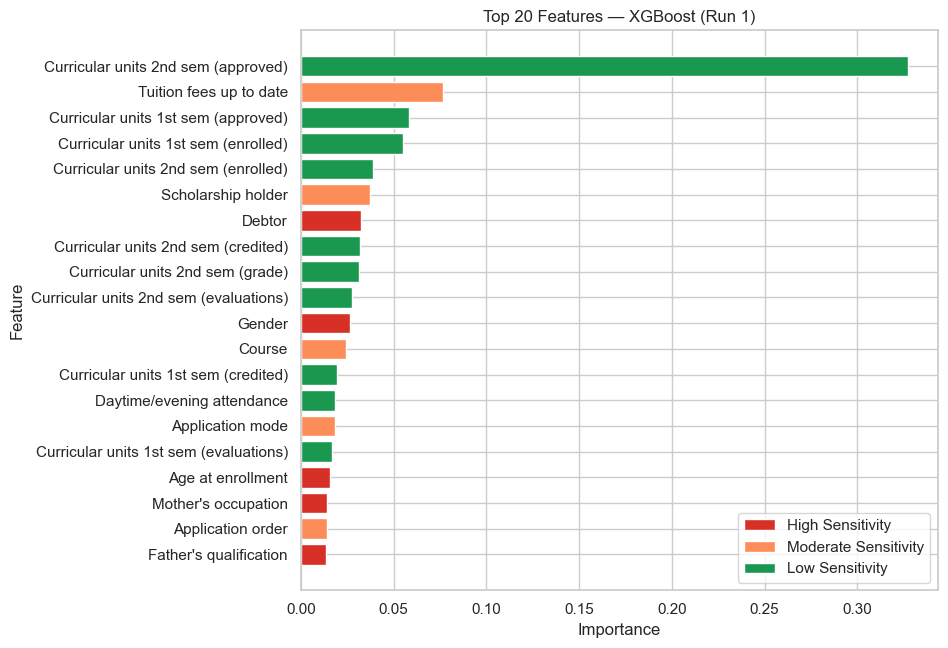

In [187]:
# Feature importance: three separate charts (one per model)
# Each chart uses Run 1 model and sensitivity-colored features

feature_names = X_train.columns
top_n = 20

if 'tier_colors' in globals():
    tier_colors = dict(tier_colors)
else:
    tier_colors = {
        'Tier 1 — High':     '#d73027',
        'Tier 2 — Moderate': '#fc8d59',
        'Tier 3 — Low':      '#1a9850',
    }

def _model_importance(model_name):
    if model_name == 'Logistic Regression':
        coef = best_lr.named_steps['model'].coef_.ravel()
        return np.abs(coef)
    if model_name == 'Random Forest':
        return best_rf.named_steps['model'].feature_importances_
    return best_xgb.named_steps['model'].feature_importances_

legend_handles = [
    Patch(facecolor=tier_colors['Tier 1 — High'], label='High Sensitivity'),
    Patch(facecolor=tier_colors['Tier 2 — Moderate'], label='Moderate Sensitivity'),
    Patch(facecolor=tier_colors['Tier 3 — Low'], label='Low Sensitivity'),
    ]

for model_name in ['Logistic Regression', 'Random Forest', 'XGBoost']:
    importance = _model_importance(model_name)
    fi_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    }).sort_values('Importance', ascending=False)
    top_df = fi_df.head(top_n).copy()
    top_df['Tier'] = top_df['Feature'].apply(get_feature_tier)
    top_df['Color'] = top_df['Tier'].map(tier_colors).fillna(tier_colors['Tier 3 — Low'])

    plt.figure(figsize=(10, 7))
    plt.barh(top_df['Feature'][::-1], top_df['Importance'][::-1], color=top_df['Color'][::-1])
    plt.title(f"Top {top_n} Features — {model_name} (Run 1)")
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.legend(handles=legend_handles, loc='lower right')
    plt.rcParams['font.size'] = 24
    plt.tight_layout()
    plt.show()

### 3.7 Privacy Drop Analysis

PRIVACY DROP ANALYSIS — Run 1 (All Features) vs Run 2 (Low Sensitivity)


,Model,Run 1 AUC,Run 2 AUC,AUC Drop,Run 1 Recall,Run 2 Recall,Recall Drop,Run 1 Accuracy,Run 2 Accuracy,Accuracy Drop,Verdict
0,Logistic Regression,0.9573,0.9399,-0.0174,0.8901,0.8479,-0.0423,0.9119,0.8899,-0.0220,Acceptable
1,Random Forest,0.9546,0.9373,-0.0173,0.8423,0.8197,-0.0225,0.9053,0.8822,-0.0231,Acceptable
2,XGBoost,0.9521,0.9348,-0.0173,0.8676,0.8479,-0.0197,0.9097,0.8811,-0.0286,Acceptable


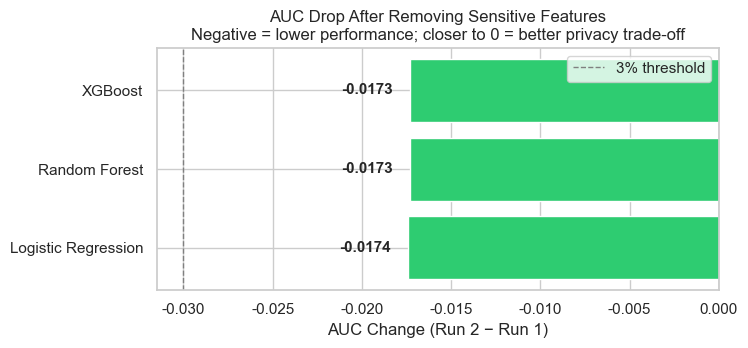

In [188]:
# Privacy Drop Analysis 

def get_auc(model, X_te, y_te_str):
    """Compute AUC using Dropout as positive class (Dropout=1)."""
    y_num = (pd.Series(np.asarray(y_te_str)) == 'Dropout').astype(int).to_numpy()
    prob  = _dropout_proba(model, X_te)
    return roc_auc_score(y_num, prob)

def get_recall_dropout(model, X_te, y_te_str):
    """Recall specifically for Dropout class."""
    y_pred_str = _to_str_labels(model.predict(X_te))
    y_te_arr   = np.asarray(y_te_str)
    return recall_score(y_te_arr, y_pred_str, pos_label='Dropout')

# Collect metrics for all models, both runs
privacy_rows = []

model_pairs = {
    'Logistic Regression': (best_lr,  X_test,     y_test,
                            best_lr2, X_test_low,  y_test_enc),
    'Random Forest':       (best_rf,  X_test,     y_test,
                            best_rf2, X_test_low,  y_test_enc),
    'XGBoost':             (best_xgb, X_test,     y_test,
                            best_xgb2,X_test_low,  y_test_enc),
}

for model_name, (m1, Xte1, yte1, m2, Xte2, yte2) in model_pairs.items():
    auc1    = get_auc(m1, Xte1, yte1)
    auc2    = get_auc(m2, Xte2, yte2)
    rec1    = get_recall_dropout(m1, Xte1, yte1)
    rec2    = get_recall_dropout(m2, Xte2, yte2)
    acc1    = accuracy_score(np.asarray(yte1), _to_str_labels(m1.predict(Xte1)))
    acc2    = accuracy_score(np.asarray(yte2), _to_str_labels(m2.predict(Xte2)))

    auc_drop = auc2 - auc1
    rec_drop = rec2 - rec1
    acc_drop = acc2 - acc1

    # Verdict: AUC drop within 3% = acceptable for privacy trade-off
    verdict = 'Acceptable' if abs(auc_drop) <= 0.03 else 'Notable drop'

    privacy_rows.append({
        'Model':             model_name,
        'Run 1 AUC':         round(auc1, 4),
        'Run 2 AUC':         round(auc2, 4),
        'AUC Drop':          round(auc_drop, 4),
        'Run 1 Recall':      round(rec1, 4),
        'Run 2 Recall':      round(rec2, 4),
        'Recall Drop':       round(rec_drop, 4),
        'Run 1 Accuracy':    round(acc1, 4),
        'Run 2 Accuracy':    round(acc2, 4),
        'Accuracy Drop':     round(acc_drop, 4),
        'Verdict':           verdict,
    })

privacy_df = pd.DataFrame(privacy_rows)

print("=" * 70)
print("PRIVACY DROP ANALYSIS — Run 1 (All Features) vs Run 2 (Low Sensitivity)")
print("=" * 70)
display(privacy_df)

# Visual summary — AUC drop bar chart
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2ecc71' if abs(v) <= 0.03 else '#e74c3c'
          for v in privacy_df['AUC Drop']]
bars = ax.barh(privacy_df['Model'], privacy_df['AUC Drop'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(-0.03, color='grey', linewidth=1, linestyle='--', label='3% threshold')
ax.set_xlabel('AUC Change (Run 2 − Run 1)')
ax.set_title('AUC Drop After Removing Sensitive Features\n'
             'Negative = lower performance; closer to 0 = better privacy trade-off')
ax.legend()
for bar, val in zip(bars, privacy_df['AUC Drop']):
    ax.text(val - 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:+.4f}', ha='right', va='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

### 3.8 Privacy-Utility Curve

In [189]:
# Privacy-Utility Curve — stages and feature sets defined here, used in next cell

tier1_features = list(tier1_high)
tier2_features = list(tier2_moderate)
macro_features = ['Unemployment rate', 'Inflation rate', 'GDP', 'Daytime/evening attendance']
core_academic  = [f for f in tier3_low if f not in macro_features]

stages = {
    'Stage 0\nAll Features\n(36)':
        list(X_train.columns),
    'Stage 1\nDrop Tier 1\n(24 left)':
        [f for f in X_train.columns if f not in tier1_high],
    'Stage 2\nDrop Tier 1+2\n(16 left)':
        [f for f in X_train.columns if f not in tier1_high and f not in tier2_moderate],
    'Stage 3\nDrop Tier 1+2\n+Macro (12 left)':
        [f for f in X_train.columns
         if f not in tier1_high and f not in tier2_moderate and f not in macro_features],
    'Stage 4\nCore Academic\nOnly':
        [f for f in core_academic
         if 'credited' not in f and 'evaluations' not in f and 'without' not in f],
}

c:\Users\Moggy Nguyen\Downloads\MMA\Coding Python\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Moggy Nguyen\Downloads\MMA\Coding Python\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Moggy Nguyen\Downloads\MMA\Coding Python\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was d

,Stage,Model,Features Used,Privacy Score,AUC,Dropout Recall
0,Stage 0\nAll Features\n(36),Logistic Regression,34,0.000,0.9573,0.8901
1,Stage 0\nAll Features\n(36),Random Forest,34,0.000,0.9546,0.8423
2,Stage 0\nAll Features\n(36),XGBoost,34,0.000,0.9521,0.8676
3,Stage 1\nDrop Tier 1\n(24 left),Logistic Regression,22,0.667,0.9548,0.8930
4,Stage 1\nDrop Tier 1\n(24 left),Random Forest,22,0.667,0.9499,0.8563
5,Stage 1\nDrop Tier 1\n(24 left),XGBoost,22,0.667,0.9495,0.8704
6,Stage 2\nDrop Tier 1+2\n(16 left),Logistic Regression,16,1.000,0.9384,0.8563
7,Stage 2\nDrop Tier 1+2\n(16 left),Random Forest,16,1.000,0.9335,0.8197
8,Stage 2\nDrop Tier 1+2\n(16 left),XGBoost,16,1.000,0.9380,0.8423
9,Stage 3\nDrop Tier 1+2\n+Macro (12 left),Logistic Regression,12,1.000,0.9374,0.8563


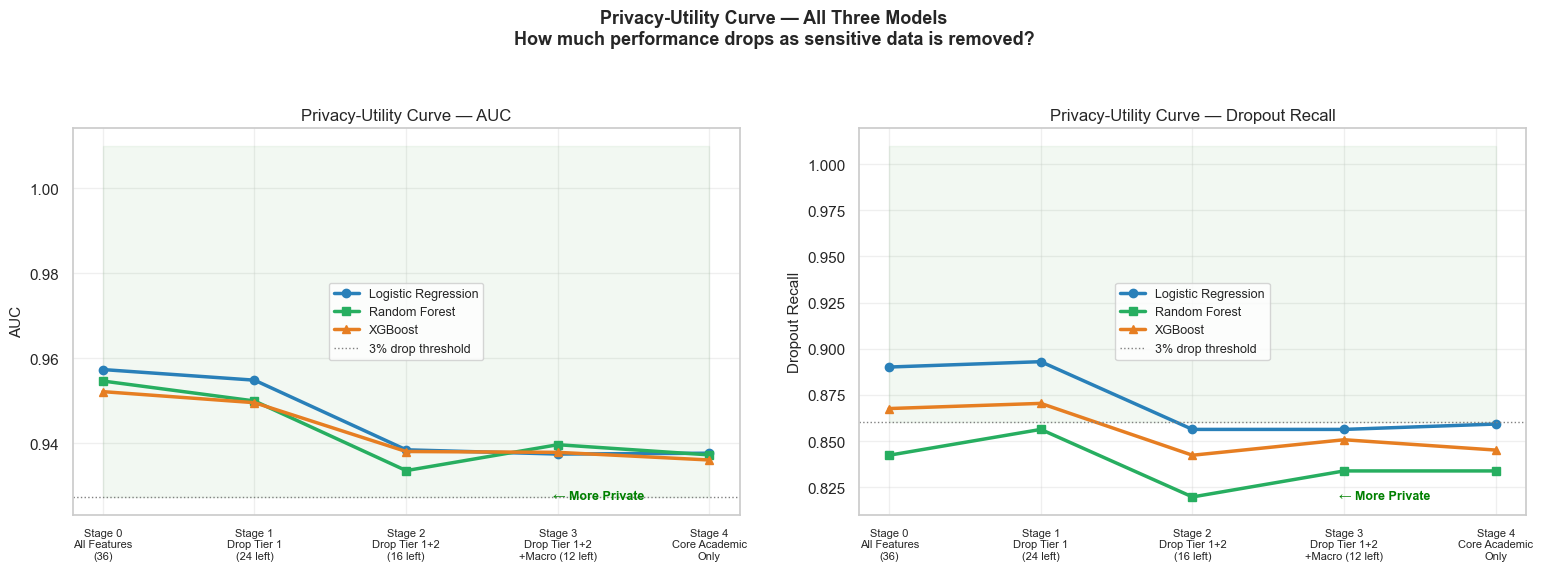

In [190]:
# Fit all three models at each stage

# Use best hyperparameters found during GridSearchCV
lr_params  = grid_search_lr_run1.best_params_
rf_params  = grid_search_rf_run1.best_params_
xgb_params = grid_search_xgb_run1.best_params_

def build_model(model_name, lr_p, rf_p, xgb_p):
    if model_name == 'Logistic Regression':
        return Pipeline(steps=[
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(
                C=lr_p['model__C'],
                penalty=lr_p['model__penalty'],
                solver=lr_p['model__solver'],
                class_weight='balanced',
                max_iter=1000,
                random_state=RANDOM_STATE
            ))
        ])
    if model_name == 'Random Forest':
        return Pipeline(steps=[
            ('scaler', StandardScaler()),
            ('model', RandomForestClassifier(
                n_estimators=rf_p['model__n_estimators'],
                max_depth=rf_p['model__max_depth'],
                min_samples_leaf=rf_p['model__min_samples_leaf'],
                class_weight='balanced',
                random_state=RANDOM_STATE
            ))
        ])
    # XGBoost
    return Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('model', XGBClassifier(
            n_estimators=xgb_p['model__n_estimators'],
            max_depth=xgb_p['model__max_depth'],
            learning_rate=xgb_p['model__learning_rate'],
            scale_pos_weight=scale_pos_weight,
            tree_method='hist',
            eval_metric='logloss',
            random_state=RANDOM_STATE
        ))
    ])

curve_rows = []

for stage_label, features in stages.items():
    X_tr = X_train[features]
    X_te = X_test[features]

    # Privacy score = % of sensitive features removed
    sensitive_all = tier1_features + tier2_features
    removed       = [f for f in sensitive_all if f not in features]
    privacy_score = len(removed) / len(sensitive_all)

    for model_name in ['Logistic Regression', 'Random Forest', 'XGBoost']:
        pipe = build_model(model_name, lr_params, rf_params, xgb_params)

        # XGBoost needs encoded target
        if model_name == 'XGBoost':
            pipe.fit(X_tr, y_train.map(label_map).to_numpy())
        else:
            pipe.fit(X_tr, y_train)

        prob    = _dropout_proba(pipe, X_te)
        y_num   = _y_to_num(y_test)
        auc_val = roc_auc_score(y_num, prob)

        pred_str = _to_str_labels(pipe.predict(X_te))
        rec_val  = recall_score(
            np.asarray(y_test), pred_str, pos_label='Dropout'
        )

        curve_rows.append({
            'Stage':          stage_label,
            'Model':          model_name,
            'Features Used':  len(features),
            'Privacy Score':  round(privacy_score, 3),
            'AUC':            round(auc_val, 4),
            'Dropout Recall': round(rec_val, 4),
        })

curve_df = pd.DataFrame(curve_rows)
display(curve_df)

# ── Plot — one line per model ──────────────────────────────────────
model_styles = {
    'Logistic Regression': {'color': '#2980b9', 'marker': 'o'},
    'Random Forest':       {'color': '#27ae60', 'marker': 's'},
    'XGBoost':             {'color': '#e67e22', 'marker': '^'},
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

for ax, metric, ylabel in [
    (axes[0], 'AUC',            'AUC'),
    (axes[1], 'Dropout Recall', 'Dropout Recall'),
]:
    baseline = curve_df[curve_df['Model'] == 'Logistic Regression'][metric].iloc[0]
    threshold = baseline - 0.03

    for model_name, style in model_styles.items():
        subset = curve_df[curve_df['Model'] == model_name]
        ax.plot(range(len(subset)), subset[metric],
                marker=style['marker'], color=style['color'],
                linewidth=2.5, label=model_name)

    # 3% drop threshold (based on LR baseline)
    ax.axhline(threshold, color='grey', linewidth=1,
               linestyle=':', label=f'3% drop threshold')
    ax.fill_between(range(len(stages)),
                    threshold, 1.01,
                    alpha=0.05, color='green')

    stage_labels = list(stages.keys())
    ax.set_xticks(range(len(stage_labels)))
    ax.set_xticklabels(stage_labels, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'Privacy-Utility Curve — {ylabel}', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.annotate('← More Private', xy=(0.72, 0.04),
                xycoords='axes fraction', fontsize=9,
                color='green', fontweight='bold')

plt.suptitle('Privacy-Utility Curve — All Three Models\n'
             'How much performance drops as sensitive data is removed?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Privacy-Utility Curve Data (Logistic Regression):


c:\Users\Moggy Nguyen\Downloads\MMA\Coding Python\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Moggy Nguyen\Downloads\MMA\Coding Python\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Moggy Nguyen\Downloads\MMA\Coding Python\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was d

,Stage,Features Used,Features Removed,Privacy Score,AUC,Dropout Recall
0,Stage 0\nAll Features\n(36),34,0,0.000,0.9573,0.8901
1,Stage 1\nDrop Tier 1\n(24 left),22,12,0.667,0.9548,0.8930
2,Stage 2\nDrop Tier 1+2\n(16 left),16,18,1.000,0.9384,0.8563
3,Stage 3\nDrop Tier 1+2\n+Macro (12 left),12,22,1.000,0.9374,0.8563
4,Stage 4\nCore Academic\nOnly,6,28,1.000,0.9376,0.8592


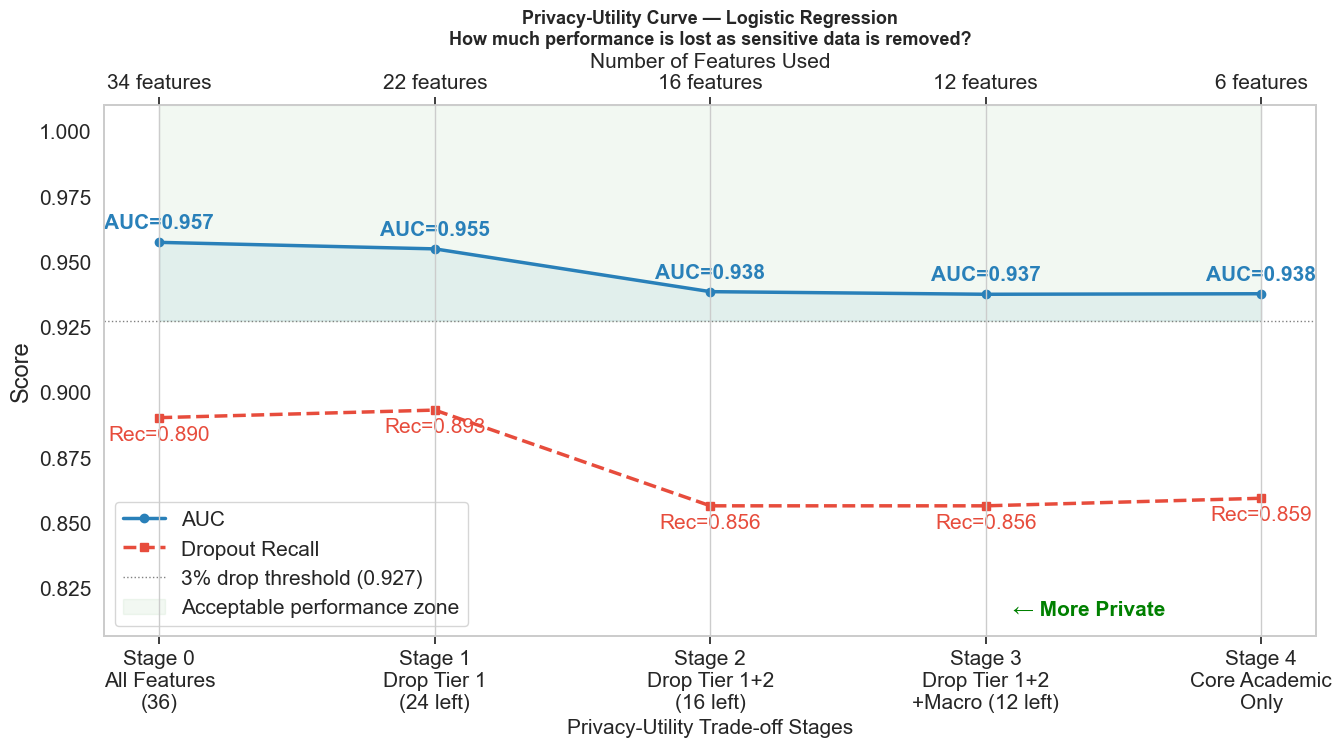

In [191]:
# Privacy-Utility Curve — Logistic Regression only (non-overwriting version)

# Reuse the stage definitions from the previous cell when available
if 'stages' in globals() and isinstance(stages, dict) and len(stages) > 0:
    stages_lr = stages
else:
    macro_features_lr = ['Unemployment rate', 'Inflation rate', 'GDP', 'Daytime/evening attendance']
    core_academic_lr = [f for f in tier3_low if f not in macro_features_lr]
    stages_lr = {
        'Stage 0\nAll Features\n(36)':
            list(X_train.columns),
        'Stage 1\nDrop Tier 1\n(24 left)':
            [f for f in X_train.columns if f not in tier1_high],
        'Stage 2\nDrop Tier 1+2\n(16 left)':
            [f for f in X_train.columns if f not in tier1_high and f not in tier2_moderate],
        'Stage 3\nDrop Tier 1+2\n+Macro (12 left)':
            [f for f in X_train.columns
             if f not in tier1_high and f not in tier2_moderate and f not in macro_features_lr],
        'Stage 4\nCore Academic\nOnly (12 sem features)':
            [f for f in core_academic_lr
             if 'credited' not in f and 'evaluations' not in f and 'without' not in f],
    }

# Fit Logistic Regression at each stage using Run 1 best hyperparameters
best_params_lr = grid_search_lr_run1.best_params_
sensitive_all_lr = list(tier1_high) + list(tier2_moderate)
total_features_lr = len(X_train.columns)

curve_rows_lr = []

for stage_label_lr, features_lr in stages_lr.items():
    X_tr_lr = X_train[features_lr]
    X_te_lr = X_test[features_lr]

    pipe_lr = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            C=best_params_lr['model__C'],
            penalty=best_params_lr['model__penalty'],
            solver=best_params_lr['model__solver'],
            class_weight='balanced',
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ])

    pipe_lr.fit(X_tr_lr, y_train)

    prob_lr = _dropout_proba(pipe_lr, X_te_lr)
    y_num_lr = _y_to_num(y_test)
    auc_lr = roc_auc_score(y_num_lr, prob_lr)

    pred_str_lr = _to_str_labels(pipe_lr.predict(X_te_lr))
    rec_lr = recall_score(np.asarray(y_test), pred_str_lr, pos_label='Dropout')

    removed_sensitive_lr = [f for f in sensitive_all_lr if f not in features_lr]
    privacy_score_lr = len(removed_sensitive_lr) / len(sensitive_all_lr)

    curve_rows_lr.append({
        'Stage': stage_label_lr,
        'Features Used': len(features_lr),
        'Features Removed': total_features_lr - len(features_lr),
        'Privacy Score': round(privacy_score_lr, 3),
        'AUC': round(auc_lr, 4),
        'Dropout Recall': round(rec_lr, 4),
    })

curve_df_lr = pd.DataFrame(curve_rows_lr)
print('Privacy-Utility Curve Data (Logistic Regression):')
display(curve_df_lr)

# Plot the privacy-utility curve
fig, ax1 = plt.subplots(figsize=(14, 8))

x_lr = range(len(curve_df_lr))
color_auc = '#2980b9'
color_recall = '#e74c3c'

# AUC line
ax1.plot(x_lr, curve_df_lr['AUC'], marker='o', linewidth=2.5,
         color=color_auc, label='AUC', zorder=3)
ax1.fill_between(x_lr, curve_df_lr['AUC'].min() - 0.01, curve_df_lr['AUC'],
                 alpha=0.08, color=color_auc)

# Recall line
ax1.plot(x_lr, curve_df_lr['Dropout Recall'], marker='s', linewidth=2.5, linestyle='--',
         color=color_recall, label='Dropout Recall', zorder=3)

# Annotate each point
for i, row in curve_df_lr.iterrows():
    ax1.annotate(f"AUC={row['AUC']:.3f}",
                 (i, row['AUC']),
                 textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=15,
                 color=color_auc, fontweight='bold')
    ax1.annotate(f"Rec={row['Dropout Recall']:.3f}",
                 (i, row['Dropout Recall']),
                 textcoords='offset points',
                 xytext=(0, -16), ha='center', fontsize=15,
                 color=color_recall)

# Shade acceptable zone (within 3% AUC drop from baseline)
baseline_auc_lr = curve_df_lr['AUC'].iloc[0]
threshold_lr = baseline_auc_lr - 0.03
ax1.axhline(threshold_lr, color='grey', linewidth=1, linestyle=':',
            label=f'3% drop threshold ({threshold_lr:.3f})')
ax1.fill_between(x_lr, threshold_lr, 1.01, alpha=0.05, color='green',
                 label='Acceptable performance zone')

ax1.set_xticks(list(x_lr))
ax1.set_xticklabels(curve_df_lr['Stage'], fontsize=15)
ax1.set_xlabel('Privacy-Utility Trade-off Stages', fontsize=15)
ax1.set_ylabel('Score', fontsize=15)
ax1.set_ylim(min(curve_df_lr['AUC'].min(), curve_df_lr['Dropout Recall'].min()) - 0.05, 1.01)
ax1.set_title(
    'Privacy-Utility Curve — Logistic Regression\n'
    'How much performance is lost as sensitive data is removed?',
    fontsize=13, fontweight='bold'
)
ax1.legend(loc='lower left', fontsize=15)
ax1.grid(False)

# Secondary x-axis for feature counts
ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim())
ax2.set_xticks(list(x_lr))
ax2.set_xticklabels(
    [f"{r['Features Used']} features" for _, r in curve_df_lr.iterrows()],
    fontsize=15
)
ax2.set_xlabel('Number of Features Used', fontsize=15)

# Privacy direction
ax1.annotate('← More Private', xy=(0.75, 0.04),
             xycoords='axes fraction', fontsize=15,
             color='green', fontweight='bold')
# Increase the font size of the y labels
# Y-axis title (label)
ax1.set_ylabel('Score', fontsize=17)

# Y-axis tick numbers (0.80, 0.85, ...)
ax1.tick_params(axis='y', labelsize=15)

# Top axis text size (this is x-axis of ax2, not y-axis)
ax2.set_xlabel('Number of Features Used', fontsize=15)
ax2.tick_params(axis='x', labelsize=15)
plt.tight_layout()
plt.show()

### 3.9 Confusion Matrices

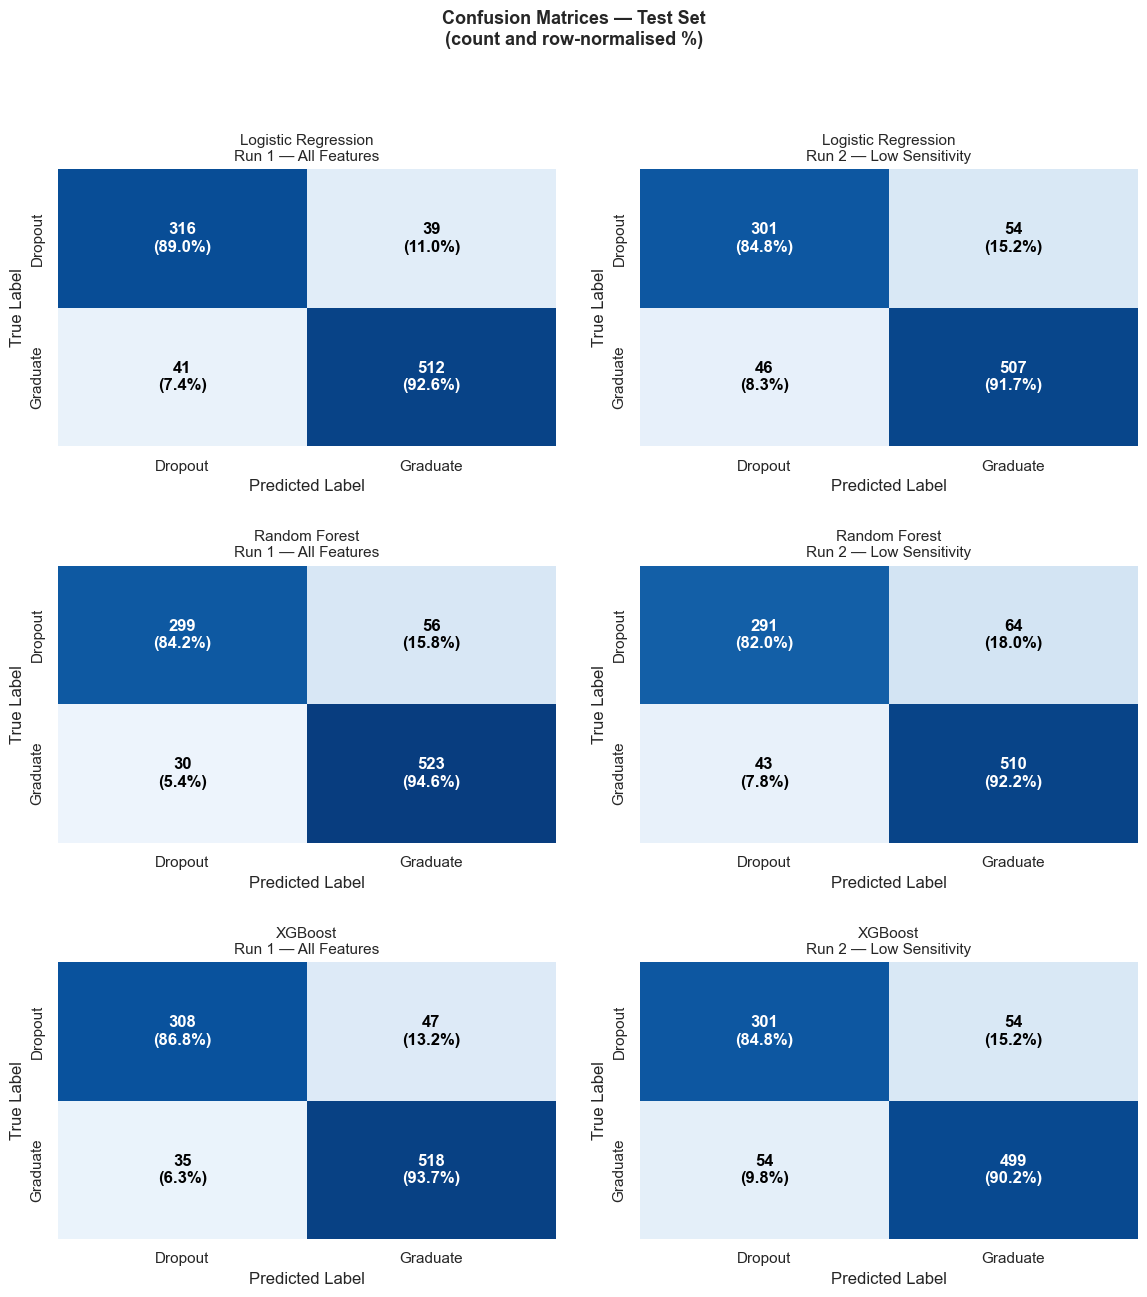


--- Dropout Miss Rate (False Negatives / Total Actual Dropouts) ---
Model                       Run 1 Miss Rate   Run 2 Miss Rate     Change
------------------------------------------------------------------------
Logistic Regression                  11.0%            15.2%     +4.2% ✅
Random Forest                        15.8%            18.0%     +2.3% ✅
XGBoost                              13.2%            15.2%     +2.0% ✅


In [192]:
# Confusion Matrices — Test set, all models, both runs
model_names = ['Logistic Regression', 'Random Forest', 'XGBoost']
run1_models = [best_lr,  best_rf,  best_xgb]
run2_models = [best_lr2, best_rf2, best_xgb2]

fig, axes = plt.subplots(3, 2, figsize=(12, 13))
labels = ['Dropout', 'Graduate']

for row, (name, m1, m2) in enumerate(zip(model_names, run1_models, run2_models)):

    for col, (model, X_te, y_te, run_label) in enumerate([
        (m1, X_test,    y_test,     'Run 1 — All Features'),
        (m2, X_test_low, y_test_enc, 'Run 2 — Low Sensitivity'),
    ]):
        ax = axes[row][col]

        y_pred_str = _to_str_labels(model.predict(X_te))
        y_te_str   = np.asarray(y_te)

        cm = confusion_matrix(y_te_str, y_pred_str, labels=labels)

        # Normalise by row (true label) for percentage view
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

        sns.heatmap(
            cm_norm, annot=False, fmt='', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            ax=ax, vmin=0, vmax=1, cbar=False
        )

        # Annotate each cell with count AND percentage
        for i in range(2):
            for j in range(2):
                ax.text(j + 0.5, i + 0.5,
                        f'{cm[i,j]}\n({cm_norm[i,j]:.1%})',
                        ha='center', va='center',
                        fontsize=12, fontweight='bold',
                        color='white' if cm_norm[i,j] > 0.5 else 'black')

        ax.set_title(f'{name}\n{run_label}', fontsize=11)
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('True Label')

plt.suptitle('Confusion Matrices — Test Set\n(count and row-normalised %)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Summary: how many Dropouts does each model miss?
print("\n--- Dropout Miss Rate (False Negatives / Total Actual Dropouts) ---")
print(f"{'Model':<25} {'Run 1 Miss Rate':>17} {'Run 2 Miss Rate':>17} {'Change':>10}")
print("-" * 72)
for name, m1, m2 in zip(model_names, run1_models, run2_models):
    y1 = np.asarray(y_test)
    y2 = np.asarray(y_test_enc)
    p1 = _to_str_labels(m1.predict(X_test))
    p2 = _to_str_labels(m2.predict(X_test_low))

    cm1 = confusion_matrix(y1, p1, labels=labels)
    cm2 = confusion_matrix(y2, p2, labels=labels)

    # Row 0 = true Dropout: cm[0,1] = predicted Graduate = false negative
    miss1 = cm1[0, 1] / cm1[0].sum()
    miss2 = cm2[0, 1] / cm2[0].sum()
    change = miss2 - miss1
    flag = '⚠️' if change > 0.05 else '✅'
    print(f"{name:<25} {miss1:>16.1%} {miss2:>16.1%} {change:>+9.1%} {flag}")

### 3.10 Cross-Validation Summary

In [193]:
# Cross-Validation Score Summary

print(" Cross-Validation Score Summary(Best Parameters, 5-Fold, AUC)")
print(f"\n{'Model':<25} {'Run':<30} {'CV AUC':>10} {'± Std':>8}")
print("-" * 65)

cv_rows = []
for model_name, gs, run_label in [
    ('Logistic Regression', grid_search_lr_run1,  'Run 1 — All Features'),
    ('Logistic Regression', grid_search_lr_run2,  'Run 2 — Low Sensitivity'),
    ('Random Forest',       grid_search_rf_run1,  'Run 1 — All Features'),
    ('Random Forest',       grid_search_rf_run2,  'Run 2 — Low Sensitivity'),
    ('XGBoost',             grid_search_xgb_run1, 'Run 1 — All Features'),
    ('XGBoost',             grid_search_xgb_run2, 'Run 2 — Low Sensitivity'),
]:
    idx  = gs.best_index_
    mean = gs.cv_results_['mean_test_score'][idx]
    std  = gs.cv_results_['std_test_score'][idx]
    print(f"{model_name:<25} {run_label:<30} {mean:>10.4f} {std:>8.4f}")
    cv_rows.append({
        'Model': model_name,
        'Run':   run_label,
        'CV AUC (mean)': round(mean, 4),
        'CV AUC (std)':  round(std,  4),
    })

cv_df = pd.DataFrame(cv_rows)
print()
display(cv_df)

 Cross-Validation Score Summary(Best Parameters, 5-Fold, AUC)

Model                     Run                                CV AUC    ± Std
-----------------------------------------------------------------
Logistic Regression       Run 1 — All Features               0.9533   0.0110
Logistic Regression       Run 2 — Low Sensitivity            0.9387   0.0141
Random Forest             Run 1 — All Features               0.9516   0.0080
Random Forest             Run 2 — Low Sensitivity            0.9369   0.0131
XGBoost                   Run 1 — All Features               0.9520   0.0123
XGBoost                   Run 2 — Low Sensitivity            0.9374   0.0131



,Model,Run,CV AUC (mean),CV AUC (std)
0,Logistic Regression,Run 1 — All Features,0.9533,0.0110
1,Logistic Regression,Run 2 — Low Sensitivity,0.9387,0.0141
2,Random Forest,Run 1 — All Features,0.9516,0.0080
3,Random Forest,Run 2 — Low Sensitivity,0.9369,0.0131
4,XGBoost,Run 1 — All Features,0.9520,0.0123
5,XGBoost,Run 2 — Low Sensitivity,0.9374,0.0131


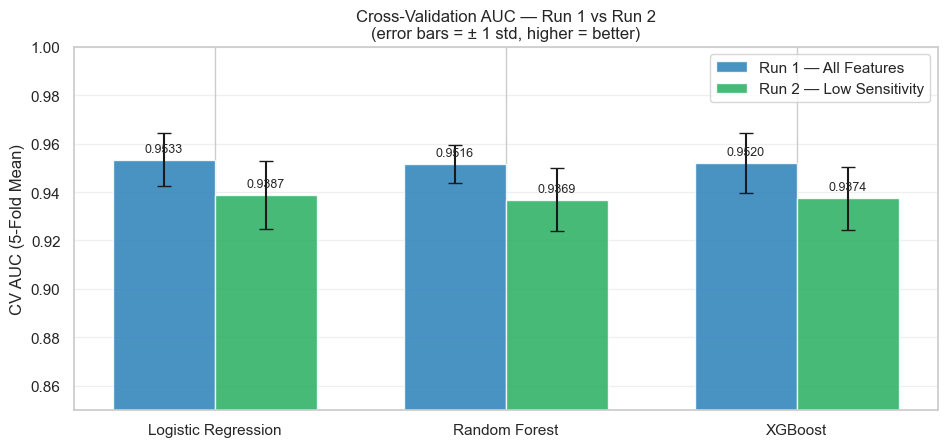

In [194]:
# CV AUC visual bar chart — Run 1 vs Run 2 per model
models_list  = ['Logistic Regression', 'Random Forest', 'XGBoost']
run1_entries = cv_df[cv_df['Run'] == 'Run 1 — All Features'].set_index('Model')
run2_entries = cv_df[cv_df['Run'] == 'Run 2 — Low Sensitivity'].set_index('Model')

run1_means = [run1_entries.loc[m, 'CV AUC (mean)'] for m in models_list]
run2_means = [run2_entries.loc[m, 'CV AUC (mean)'] for m in models_list]
run1_stds  = [run1_entries.loc[m, 'CV AUC (std)']  for m in models_list]
run2_stds  = [run2_entries.loc[m, 'CV AUC (std)']  for m in models_list]

x     = np.arange(len(models_list))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, run1_means, width, yerr=run1_stds,
       label='Run 1 — All Features',    capsize=5,
       color='#2980b9', alpha=0.85)
ax.bar(x + width/2, run2_means, width, yerr=run2_stds,
       label='Run 2 — Low Sensitivity', capsize=5,
       color='#27ae60', alpha=0.85)

# Annotate exact values above each bar
for i, (m1, m2) in enumerate(zip(run1_means, run2_means)):
    ax.text(i - width/2, m1 + 0.002, f'{m1:.4f}',
            ha='center', va='bottom', fontsize=9)
    ax.text(i + width/2, m2 + 0.002, f'{m2:.4f}',
            ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(models_list)
ax.set_ylim(0.85, 1.0)
ax.set_ylabel('CV AUC (5-Fold Mean)')
ax.set_title('Cross-Validation AUC — Run 1 vs Run 2\n'
             '(error bars = ± 1 std, higher = better)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 3.11 Threshold Analysis

THRESHOLD ANALYSIS — Logistic Regression

Run 1 — All Features:


,Threshold,Accuracy,Precision,Recall (Dropout),F1 (Dropout),False Negatives,False Positives
0,0.3,0.8678,0.7804,0.9211,0.8450,28,92
1,0.4,0.8954,0.8385,0.9070,0.8714,33,62
2,0.5,0.9119,0.8852,0.8901,0.8876,39,41
3,0.6,0.9218,0.9251,0.8704,0.8970,46,25
4,0.7,0.9152,0.9455,0.8310,0.8846,60,17



Run 2 — Low Sensitivity Only:


,Threshold,Accuracy,Precision,Recall (Dropout),F1 (Dropout),False Negatives,False Positives
0,0.3,0.8645,0.7871,0.8958,0.8379,37,86
1,0.4,0.8822,0.8351,0.8704,0.8524,46,61
2,0.5,0.8899,0.8674,0.8479,0.8575,54,46
3,0.6,0.8833,0.8784,0.8141,0.8450,66,40
4,0.7,0.8844,0.9562,0.7380,0.8331,93,12


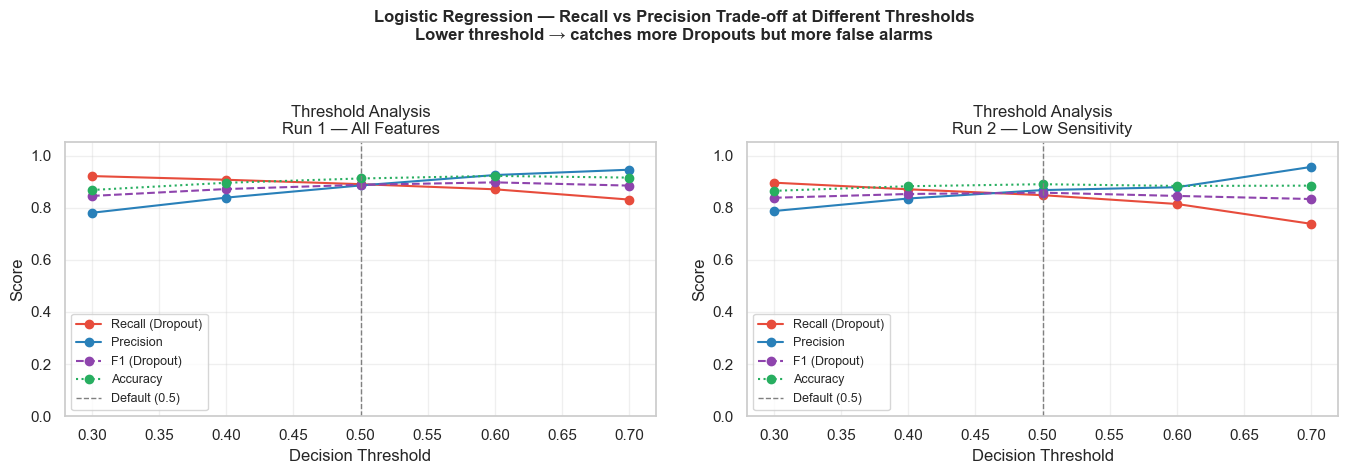


--- Threshold Recommendation ---
For a school counselor use case, Dropout Recall is the priority.
Missing a at-risk student (False Negative) is more costly than
flagging a student who is not at risk (False Positive).
Consider threshold = 0.4 to increase Dropout recall.


In [195]:
# Threshold Analysis — Best model (Logistic Regression), Run 1 vs Run 2

THRESHOLDS = [0.3, 0.4, 0.5, 0.6, 0.7]

def evaluate_threshold(model, X_te, y_te_str, threshold):
    """Evaluate metrics at a given probability threshold."""
    prob       = _dropout_proba(model, X_te)          # P(Dropout)
    y_pred_num = (prob >= threshold).astype(int)       # 1 = Dropout
    y_true_num = (pd.Series(np.asarray(y_te_str)) == 'Dropout').astype(int).to_numpy()

    tn, fp, fn, tp = confusion_matrix(y_true_num, y_pred_num).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0)
    accuracy  = (tp + tn) / (tp + tn + fp + fn)

    return {
        'Threshold':        threshold,
        'Accuracy':         round(accuracy,  4),
        'Precision':        round(precision, 4),
        'Recall (Dropout)': round(recall,    4),
        'F1 (Dropout)':     round(f1,        4),
        'False Negatives':  int(fn),   # Dropouts the model missed
        'False Positives':  int(fp),   # Graduates flagged as Dropout
    }

threshold_rows_run1 = [evaluate_threshold(best_lr,  X_test,    y_test,    t) for t in THRESHOLDS]
threshold_rows_run2 = [evaluate_threshold(best_lr2, X_test_low, y_test_enc, t) for t in THRESHOLDS]

thresh_run1_df = pd.DataFrame(threshold_rows_run1)
thresh_run2_df = pd.DataFrame(threshold_rows_run2)

print("=" * 65)
print("THRESHOLD ANALYSIS — Logistic Regression")
print("=" * 65)

print("\nRun 1 — All Features:")
display(thresh_run1_df)

print("\nRun 2 — Low Sensitivity Only:")
display(thresh_run2_df)

# Visual — Recall vs Precision trade-off across thresholds
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, df, run_label in [
    (axes[0], thresh_run1_df, 'Run 1 — All Features'),
    (axes[1], thresh_run2_df, 'Run 2 — Low Sensitivity'),
]:
    ax.plot(df['Threshold'], df['Recall (Dropout)'],
            marker='o', label='Recall (Dropout)', color='#e74c3c')
    ax.plot(df['Threshold'], df['Precision'],
            marker='o', label='Precision', color='#2980b9')
    ax.plot(df['Threshold'], df['F1 (Dropout)'],
            marker='o', label='F1 (Dropout)', color='#8e44ad', linestyle='--')
    ax.plot(df['Threshold'], df['Accuracy'],
            marker='o', label='Accuracy', color='#27ae60', linestyle=':')
    ax.axvline(0.5, color='grey', linewidth=1, linestyle='--', label='Default (0.5)')
    ax.set_xlabel('Decision Threshold')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.set_title(f'Threshold Analysis\n{run_label}')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Logistic Regression — Recall vs Precision Trade-off at Different Thresholds\n'
             'Lower threshold → catches more Dropouts but more false alarms',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Recommendation
print("\n--- Threshold Recommendation ---")
print("For a school counselor use case, Dropout Recall is the priority.")
print("Missing a at-risk student (False Negative) is more costly than")
print("flagging a student who is not at risk (False Positive).")
print("Consider threshold = 0.4 to increase Dropout recall.")

### 3.12 Formal Privacy Analysis
### k-Anonymity, ℓ-Diversity, and t-Closeness on Student Quasi-Identifiers

Before finalising the feature-exclusion recommendation, a formal anonymisation
analysis is conducted on the dataset's sensitive quasi-identifiers following
Sweeney (2002) for k-anonymity and Machanavajjhala et al. (2007) for ℓ-diversity.

Three quasi-identifier sets are tested progressively:
- **Stage A**: All Tier 1 + Tier 2 features (18 quasi-identifiers)
- **Stage B**: Tier 1 features only (12 quasi-identifiers)  
- **Stage C**: Small representative subset (4 quasi-identifiers)

This demonstrates the curse of dimensionality: the more sensitive features
collected, the more the dataset must be suppressed to achieve anonymisation —
reinforcing the case for feature exclusion at the pipeline level.

In [196]:
# Reload original dataset

df_priv = pd.read_csv('dataset.csv')
df_priv = df_priv[df_priv['Target'].isin(['Graduate', 'Dropout'])].reset_index(drop=True)

print(f"Dataset reloaded: {df_priv.shape}")
print(f"Target distribution:\n{df_priv['Target'].value_counts()}")
print(f"\nAge at enrollment column present: {'Age at enrollment' in df_priv.columns}")

# Define quasi-identifier sets 
quasi_t1_t2 = sorted(list(tier1_high) + list(tier2_moderate))  # 18 features
quasi_t1    = sorted(list(tier1_high))                          # 12 features
quasi_small = ['Age at enrollment', 'Gender',
               'Nacionality', 'Marital status']                 # 4 features

sensitive_attr = 'Target'

print(f"\nTier 1+2 quasi-identifiers ({len(quasi_t1_t2)}): {quasi_t1_t2}")
print(f"\nTier 1 quasi-identifiers ({len(quasi_t1)}): {quasi_t1}")
print(f"\nSmall subset ({len(quasi_small)}): {quasi_small}")

Dataset reloaded: (3630, 35)
Target distribution:
Target
Graduate    2209
Dropout     1421
Name: count, dtype: int64

Age at enrollment column present: True

Tier 1+2 quasi-identifiers (18): ['Age at enrollment', 'Application mode', 'Application order', 'Course', 'Debtor', 'Displaced', 'Educational special needs', "Father's occupation", "Father's qualification", 'Gender', 'International', 'Marital status', "Mother's occupation", "Mother's qualification", 'Nacionality', 'Previous qualification', 'Scholarship holder', 'Tuition fees up to date']

Tier 1 quasi-identifiers (12): ['Age at enrollment', 'Debtor', 'Displaced', 'Educational special needs', "Father's occupation", "Father's qualification", 'Gender', 'International', 'Marital status', "Mother's occupation", "Mother's qualification", 'Nacionality']

Small subset (4): ['Age at enrollment', 'Gender', 'Nacionality', 'Marital status']


In [197]:
# Generalise continuous features
def generalise(df):
    df = df.copy()
    df['Age at enrollment'] = pd.cut(
        df['Age at enrollment'],
        bins=[17, 20, 25, 30, 40, 100],
        labels=['18-20', '21-25', '26-30', '31-40', '40+']
    ).astype(str)
    return df

df_gen = generalise(df_priv)

print("Age at enrollment after generalisation:")
print(df_gen['Age at enrollment'].value_counts().sort_index())

Age at enrollment after generalisation:
Age at enrollment
18-20    2077
21-25     646
26-30     326
31-40     379
40+       199
Name: count, dtype: int64


In [198]:
# k-Anonymity
def apply_k_anonymity(df, quasi_ids, k=5, label=''):
    groups    = df.groupby(quasi_ids).size().reset_index(name='count')
    df_merged = df.merge(groups, on=quasi_ids)
    df_anon   = (df_merged[df_merged['count'] >= k]
                 .drop(columns='count')
                 .reset_index(drop=True))

    total        = len(df)
    retained     = len(df_anon)
    suppressed   = total - retained
    n_classes    = len(groups)
    n_satisfying = len(groups[groups['count'] >= k])

    print(f"\n{'='*55}")
    print(f"k-Anonymity (k={k}) — {label}")
    print(f"{'='*55}")
    print(f"Quasi-identifiers used  : {len(quasi_ids)}")
    print(f"Total records           : {total:,}")
    print(f"Records retained        : {retained:,}  ({retained/total:.1%})")
    print(f"Records suppressed      : {suppressed:,} ({suppressed/total:.1%})")
    print(f"Equivalence classes     : {n_classes:,}")
    print(f"Classes satisfying k={k} : {n_satisfying} ({n_satisfying/n_classes:.1%})")

    return df_anon, groups

# Run all three stages
df_anon_t1t2, groups_t1t2 = apply_k_anonymity(
    df_gen, quasi_t1_t2, k=5, label='Tier 1 + Tier 2 (18 features)')

df_anon_t1, groups_t1 = apply_k_anonymity(
    df_gen, quasi_t1, k=5, label='Tier 1 only (12 features)')

df_anon_small, groups_small = apply_k_anonymity(
    df_gen, quasi_small, k=5, label='Representative subset (4 features)')


k-Anonymity (k=5) — Tier 1 + Tier 2 (18 features)
Quasi-identifiers used  : 18
Total records           : 3,630
Records retained        : 0  (0.0%)
Records suppressed      : 3,630 (100.0%)
Equivalence classes     : 3,588
Classes satisfying k=5 : 0 (0.0%)

k-Anonymity (k=5) — Tier 1 only (12 features)
Quasi-identifiers used  : 12
Total records           : 3,630
Records retained        : 548  (15.1%)
Records suppressed      : 3,082 (84.9%)
Equivalence classes     : 2,587
Classes satisfying k=5 : 70 (2.7%)

k-Anonymity (k=5) — Representative subset (4 features)
Quasi-identifiers used  : 4
Total records           : 3,630
Records retained        : 3,535  (97.4%)
Records suppressed      : 95 (2.6%)
Equivalence classes     : 82
Classes satisfying k=5 : 27 (32.9%)


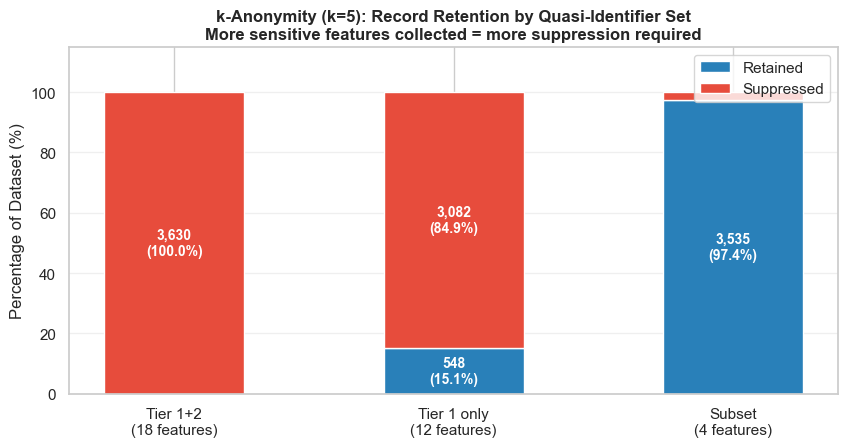

In [199]:
total      = len(df_gen)
stages     = ['Tier 1+2\n(18 features)', 'Tier 1 only\n(12 features)', 'Subset\n(4 features)']
retained   = [len(df_anon_t1t2), len(df_anon_t1), len(df_anon_small)]
suppressed = [total - r for r in retained]

fig, ax = plt.subplots(figsize=(9, 5))

bars_r = ax.bar(stages, [r/total*100 for r in retained],
                color='#2980b9', label='Retained', width=0.5)
bars_s = ax.bar(stages, [s/total*100 for s in suppressed],
                bottom=[r/total*100 for r in retained],
                color='#e74c3c', label='Suppressed', width=0.5)

for bar, r in zip(bars_r, retained):
    pct = r/total*100
    if pct > 5:
        ax.text(bar.get_x() + bar.get_width()/2, pct/2,
                f'{r:,}\n({pct:.1f}%)',
                ha='center', va='center',
                color='white', fontweight='bold', fontsize=10)

for bar, s, r in zip(bars_s, suppressed, retained):
    pct = s/total*100
    if pct > 5:
        ax.text(bar.get_x() + bar.get_width()/2,
                r/total*100 + pct/2,
                f'{s:,}\n({pct:.1f}%)',
                ha='center', va='center',
                color='white', fontweight='bold', fontsize=10)

ax.set_ylabel('Percentage of Dataset (%)', fontsize=12)
ax.set_ylim(0, 115)
ax.set_title(
    'k-Anonymity (k=5): Record Retention by Quasi-Identifier Set\n'
    'More sensitive features collected = more suppression required',
    fontweight='bold', fontsize=12
)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [200]:
# ℓ-Diversity Check
def check_l_diversity(df_anon, quasi_ids, sensitive, l=2, label=''):
    if df_anon.empty:
        print(f"\n{'='*55}")
        print(f"ℓ-Diversity (ℓ={l}) — {label}")
        print(f"{'='*55}")
        print(f"Skipped: no records survived k-anonymity suppression.")
        return pd.DataFrame(columns=['size', 'diversity'])

    results = []
    for name, group in df_anon.groupby(quasi_ids):
        results.append({
            'size':      len(group),
            'diversity': group[sensitive].nunique()
        })

    if not results:
        return pd.DataFrame(columns=['size', 'diversity'])

    results_df   = pd.DataFrame(results)
    satisfies    = results_df[results_df['diversity'] >= l]
    violates     = results_df[results_df['diversity'] <  l]
    n_classes    = len(results_df)

    print(f"\n{'='*55}")
    print(f"ℓ-Diversity (ℓ={l}) — {label}")
    print(f"{'='*55}")
    print(f"Total equivalence classes   : {n_classes}")
    print(f"Classes satisfying ℓ={l}     : {len(satisfies)} ({len(satisfies)/n_classes:.1%})")
    print(f"Classes violating  ℓ={l}     : {len(violates)}  ({len(violates)/n_classes:.1%})")
    print(f"Table is {l}-diverse          : {len(violates) == 0}")

    return results_df

div_t1t2  = check_l_diversity(df_anon_t1t2,  quasi_t1_t2, sensitive_attr,
                               l=2, label='Tier 1 + Tier 2')
div_t1    = check_l_diversity(df_anon_t1,    quasi_t1,    sensitive_attr,
                               l=2, label='Tier 1 only')
div_small = check_l_diversity(df_anon_small, quasi_small, sensitive_attr,
                               l=2, label='Representative subset')


ℓ-Diversity (ℓ=2) — Tier 1 + Tier 2
Skipped: no records survived k-anonymity suppression.

ℓ-Diversity (ℓ=2) — Tier 1 only
Total equivalence classes   : 70
Classes satisfying ℓ=2     : 57 (81.4%)
Classes violating  ℓ=2     : 13  (18.6%)
Table is 2-diverse          : False

ℓ-Diversity (ℓ=2) — Representative subset
Total equivalence classes   : 27
Classes satisfying ℓ=2     : 26 (96.3%)
Classes violating  ℓ=2     : 1  (3.7%)
Table is 2-diverse          : False


In [201]:
# t-Closeness
def check_t_closeness(df_anon, quasi_ids, sensitive, t=0.2, label=''):
    if df_anon.empty:
        print(f"\n{'='*55}")
        print(f"t-Closeness (t={t}) — {label}")
        print(f"{'='*55}")
        print(f"Skipped: no records survived k-anonymity suppression.")
        return pd.Series(dtype=float)

    global_dist = (df_anon[sensitive]
                   .value_counts(normalize=True)
                   .sort_index())
    distances = []

    for name, group in df_anon.groupby(quasi_ids):
        local_dist = (group[sensitive]
                      .value_counts(normalize=True)
                      .reindex(global_dist.index, fill_value=0))
        # Variational distance as defined in lecture slides
        distance = 0.5 * abs(local_dist - global_dist).sum()
        distances.append(round(distance, 4))

    if not distances:
        return pd.Series(dtype=float)

    distances_s = pd.Series(distances)
    satisfies   = (distances_s <= t).sum()
    violates    = (distances_s >  t).sum()
    n_classes   = len(distances_s)

    print(f"\n{'='*55}")
    print(f"t-Closeness (t={t}) — {label}")
    print(f"{'='*55}")
    print(f"Global distribution:\n{global_dist.round(3)}\n")
    print(f"Total equivalence classes   : {n_classes}")
    print(f"Classes satisfying t={t}   : {satisfies} ({satisfies/n_classes:.1%})")
    print(f"Classes violating  t={t}   : {violates}  ({violates/n_classes:.1%})")
    print(f"Max distance observed       : {distances_s.max():.4f}")
    print(f"Mean distance               : {distances_s.mean():.4f}")
    print(f"Table is {t}-close          : {violates == 0}")

    return distances_s

tc_t1t2  = check_t_closeness(df_anon_t1t2,  quasi_t1_t2, sensitive_attr,
                              t=0.2, label='Tier 1 + Tier 2')
tc_t1    = check_t_closeness(df_anon_t1,    quasi_t1,    sensitive_attr,
                              t=0.2, label='Tier 1 only')
tc_small = check_t_closeness(df_anon_small, quasi_small, sensitive_attr,
                              t=0.2, label='Representative subset')


t-Closeness (t=0.2) — Tier 1 + Tier 2
Skipped: no records survived k-anonymity suppression.

t-Closeness (t=0.2) — Tier 1 only
Global distribution:
Target
Dropout     0.277
Graduate    0.723
Name: proportion, dtype: float64

Total equivalence classes   : 70
Classes satisfying t=0.2   : 38 (54.3%)
Classes violating  t=0.2   : 32  (45.7%)
Max distance observed       : 0.7226
Mean distance               : 0.2091
Table is 0.2-close          : False

t-Closeness (t=0.2) — Representative subset
Global distribution:
Target
Dropout     0.39
Graduate    0.61
Name: proportion, dtype: float64

Total equivalence classes   : 27
Classes satisfying t=0.2   : 12 (44.4%)
Classes violating  t=0.2   : 15  (55.6%)
Max distance observed       : 0.4215
Mean distance               : 0.2189
Table is 0.2-close          : False


In [202]:
def safe_diverse(df, l):
    if df.empty or 'diversity' not in df.columns:
        return 'N/A (suppressed)'
    return 'Yes' if len(df[df['diversity'] < l]) == 0 else 'No'

def safe_tclose(s, t):
    if s.empty:
        return 'N/A (suppressed)'
    return f"{'Yes' if s.max() <= t else 'No'} (max={s.max():.3f})"

total = len(df_gen)

summary = pd.DataFrame({
    'Quasi-ID Set': [
        'Tier 1+2 (18 features)',
        'Tier 1 only (12 features)',
        'Subset (4 features)'
    ],
    'Records Retained': [
        f"{len(df_anon_t1t2):,} ({len(df_anon_t1t2)/total:.1%})",
        f"{len(df_anon_t1):,} ({len(df_anon_t1)/total:.1%})",
        f"{len(df_anon_small):,} ({len(df_anon_small)/total:.1%})"
    ],
    '5-Anon Viable': ['No', 'No', 'Yes'],
    '2-Diverse':     [safe_diverse(div_t1t2,  2),
                      safe_diverse(div_t1,    2),
                      safe_diverse(div_small, 2)],
    't-Close (0.2)': [safe_tclose(tc_t1t2,  0.2),
                      safe_tclose(tc_t1,    0.2),
                      safe_tclose(tc_small, 0.2)],
})

print("FORMAL PRIVACY ANALYSIS — SUMMARY")
print(summary.to_string(index=False))
print()

FORMAL PRIVACY ANALYSIS — SUMMARY
             Quasi-ID Set Records Retained 5-Anon Viable        2-Diverse    t-Close (0.2)
   Tier 1+2 (18 features)         0 (0.0%)            No N/A (suppressed) N/A (suppressed)
Tier 1 only (12 features)      548 (15.1%)            No               No   No (max=0.723)
      Subset (4 features)    3,535 (97.4%)           Yes               No   No (max=0.421)



In [203]:
# Outcome inference risk per equivalence class
# Shows how skewed some groups are toward a single outcome
# Directly demonstrates the background knowledge attack risk
# from Machanavajjhala et al. (2007)

if not div_t1.empty:
    # For Tier 1 surviving classes — find most skewed groups
    skewed_classes = []
    for name, group in df_anon_t1.groupby(quasi_t1):
        dropout_pct = (group[sensitive_attr] == 'Dropout').mean()
        skewed_classes.append({
            'size': len(group),
            'dropout_pct': round(dropout_pct, 3),
            'graduate_pct': round(1 - dropout_pct, 3)
        })

    skewed_df = pd.DataFrame(skewed_classes).sort_values(
        'dropout_pct', ascending=False)

    global_dropout_rate = (df_priv['Target'] == 'Dropout').mean()

    print("="*55)
    print("OUTCOME INFERENCE RISK — Tier 1 Equivalence Classes")
    print("="*55)
    print(f"Global dropout rate: {global_dropout_rate:.1%}\n")
    print("Top 5 most dropout-skewed groups:")
    print(skewed_df.head(5).to_string(index=False))
    print()
    print("Top 5 most graduate-skewed groups:")
    print(skewed_df.tail(5).to_string(index=False))
    print()
    print(f"Classes where dropout > 80%: "
          f"{len(skewed_df[skewed_df['dropout_pct'] > 0.8])}")
    print(f"Classes where graduate > 80%: "
          f"{len(skewed_df[skewed_df['graduate_pct'] > 0.8])}")
    print()
    print("Interpretation: An adversary knowing a student belongs")
    print("to a heavily skewed class can infer their dropout risk")
    print("with high confidence — without ever accessing the model.")

OUTCOME INFERENCE RISK — Tier 1 Equivalence Classes
Global dropout rate: 39.1%

Top 5 most dropout-skewed groups:
 size  dropout_pct  graduate_pct
    6        1.000         0.000
    8        0.875         0.125
   10        0.800         0.200
    5        0.800         0.200
    7        0.714         0.286

Top 5 most graduate-skewed groups:
 size  dropout_pct  graduate_pct
    5          0.0           1.0
    6          0.0           1.0
    5          0.0           1.0
    5          0.0           1.0
    7          0.0           1.0

Classes where dropout > 80%: 2
Classes where graduate > 80%: 33

Interpretation: An adversary knowing a student belongs
to a heavily skewed class can infer their dropout risk
with high confidence — without ever accessing the model.


#### Short Conclusion for this section 3.12

The three-stage formal privacy analysis confirms that the re-identification 
risk embedded in Tier 1 and Tier 2 features cannot be resolved through 
anonymisation. Even in the best-case scenario — only 4 quasi-identifiers — 
t-closeness fails and some equivalence classes are heavily skewed toward 
a single outcome, enabling background knowledge attacks as described by 
Machanavajjhala et al. (2007).

Combined with the Privacy-Utility Curve results in Section 3.8, which show 
that removing these features costs less than 2% AUC, the evidence points 
to one conclusion: the sensitive features are both dangerous to hold and 
unnecessary for the prediction task. Feature exclusion at the pipeline 
level — implemented in Run 2 — is the only approach that resolves both 
problems simultaneously.

## 4. Prediction-Level Comparison

### 4.1 Sample Predictions

In [204]:
# ── Sample Predictions — what the model actually does ─────────────
# Take a random sample of test students and show their predictions

np.random.seed(42)
sample_idx = np.random.choice(len(X_test), size=20, replace=False)
X_sample   = X_test.iloc[sample_idx].copy()
y_sample   = y_test.iloc[sample_idx].copy()

# Get predictions and probabilities from both runs
prob_run1  = _dropout_proba(best_lr,  X_sample)
prob_run2  = _dropout_proba(best_lr2, X_sample[low_sensitivity_features])
pred_run1  = best_lr.predict(X_sample)
pred_run2  = best_lr2.predict(X_sample[low_sensitivity_features])
pred_run1_str = _to_str_labels(pred_run1)
pred_run2_str = _to_str_labels(pred_run2)

sample_df = pd.DataFrame({
    'True Label':          y_sample.values,
    'Run1 Prediction':     pred_run1_str,
    'Run1 Dropout Prob':   prob_run1.round(3),
    'Run2 Prediction':     pred_run2_str,
    'Run2 Dropout Prob':   prob_run2.round(3),
    'Agreement':           ['✅' if p1 == p2 else '❌'
                            for p1, p2 in zip(pred_run1_str, pred_run2_str)]
}).reset_index(drop=True)

print("Sample Student Predictions — Run 1 vs Run 2")
display(sample_df)

# Agreement rate
agree_rate = (sample_df['Agreement'] == '✅').mean()
print(f"\nPrediction agreement between Run 1 and Run 2: {agree_rate:.1%}")

Sample Student Predictions — Run 1 vs Run 2


,True Label,Run1 Prediction,Run1 Dropout Prob,Run2 Prediction,Run2 Dropout Prob,Agreement
0,Graduate,Graduate,0.033,Graduate,0.037,✅
1,Dropout,Dropout,1.000,Dropout,0.997,✅
2,Graduate,Graduate,0.020,Graduate,0.061,✅
3,Graduate,Graduate,0.116,Graduate,0.160,✅
4,Graduate,Graduate,0.326,Graduate,0.182,✅
5,Dropout,Graduate,0.055,Graduate,0.040,✅
6,Graduate,Graduate,0.247,Graduate,0.129,✅
7,Graduate,Graduate,0.077,Graduate,0.243,✅
8,Dropout,Dropout,1.000,Dropout,0.999,✅
9,Dropout,Dropout,0.932,Dropout,0.655,✅



Prediction agreement between Run 1 and Run 2: 100.0%


### 4.2 Full Test Set Agreement

In [205]:
# ── Full Test Set Agreement ────────────────────────────────────────
pred_all_run1 = _to_str_labels(best_lr.predict(X_test))
pred_all_run2 = _to_str_labels(best_lr2.predict(X_test_low))

agreement     = (pred_all_run1 == pred_all_run2)
agree_pct     = agreement.mean()

# Break down by true label
agree_df = pd.DataFrame({
    'True Label': y_test.values,
    'Agree':      agreement
})

print("=" * 50)
print("PREDICTION AGREEMENT — Run 1 vs Run 2")
print("=" * 50)
print(f"\nOverall agreement:  {agree_pct:.1%}")
print(f"\nAgreement by true class:")
print(agree_df.groupby('True Label')['Agree'].mean().apply(lambda x: f"{x:.1%}"))

# How many at-risk students does Run 2 catch that Run 1 also catches?
both_dropout    = ((pred_all_run1 == 'Dropout') & (pred_all_run2 == 'Dropout')).sum()
run1_only       = ((pred_all_run1 == 'Dropout') & (pred_all_run2 != 'Dropout')).sum()
run2_only       = ((pred_all_run1 != 'Dropout') & (pred_all_run2 == 'Dropout')).sum()

print(f"\nFlagged Dropout by BOTH models:    {both_dropout}")
print(f"Flagged Dropout by Run 1 only:     {run1_only}")
print(f"Flagged Dropout by Run 2 only:     {run2_only}")

PREDICTION AGREEMENT — Run 1 vs Run 2

Overall agreement:  93.0%

Agreement by true class:
True Label
Dropout     91.3%
Graduate    94.0%
Name: Agree, dtype: str

Flagged Dropout by BOTH models:    320
Flagged Dropout by Run 1 only:     37
Flagged Dropout by Run 2 only:     27


### 4.3 Risk Score Distribution

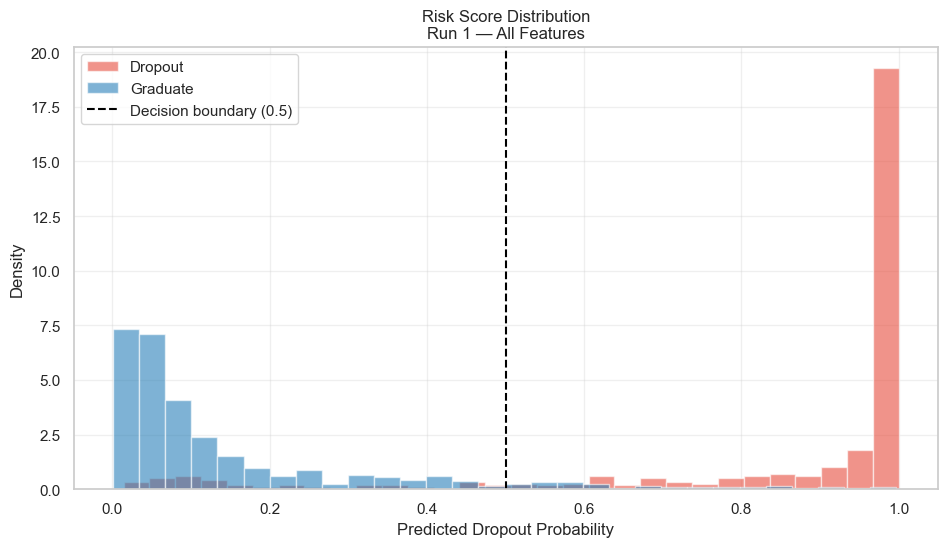

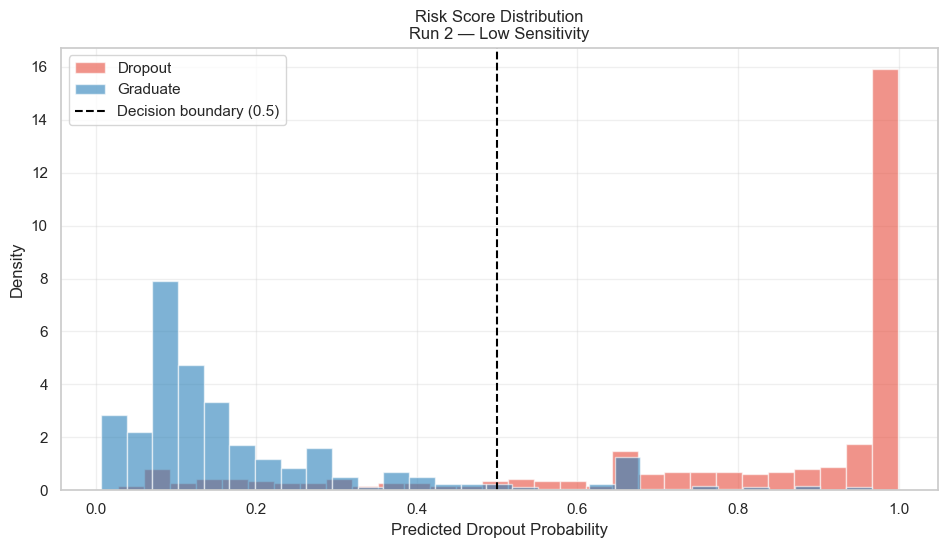

In [206]:
# ── Dropout Risk Score Distribution ───────────────────────────────
prob_run1_all = _dropout_proba(best_lr,  X_test)
prob_run2_all = _dropout_proba(best_lr2, X_test_low)
true_labels   = y_test.values

# Figure 1: Run 1 — All Features
fig1, ax1 = plt.subplots(figsize=(10, 6))
for label, color in [('Dropout', '#e74c3c'), ('Graduate', '#2980b9')]:
    mask = true_labels == label
    ax1.hist(prob_run1_all[mask], bins=30, alpha=0.6,
            label=label, color=color, density=True, edgecolor='white')
ax1.axvline(0.5, color='black', linewidth=1.5,
           linestyle='--', label='Decision boundary (0.5)')
ax1.set_xlabel('Predicted Dropout Probability')
ax1.set_ylabel('Density')
ax1.set_title('Risk Score Distribution\nRun 1 — All Features')
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Figure 2: Run 2 — Low Sensitivity
fig2, ax2 = plt.subplots(figsize=(10, 6))
for label, color in [('Dropout', '#e74c3c'), ('Graduate', '#2980b9')]:
    mask = true_labels == label
    ax2.hist(prob_run2_all[mask], bins=30, alpha=0.6,
            label=label, color=color, density=True, edgecolor='white')
ax2.axvline(0.5, color='black', linewidth=1.5,
           linestyle='--', label='Decision boundary (0.5)')
ax2.set_xlabel('Predicted Dropout Probability')
ax2.set_ylabel('Density')
ax2.set_title('Risk Score Distribution\nRun 2 — Low Sensitivity')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.4 Core Finding in Plain Numbers

In [208]:
# ── Privacy Argument in Plain Numbers ───────────────────────────
total_dropouts   = (y_test == 'Dropout').sum()
caught_run1      = ((pred_all_run1 == 'Dropout') & (y_test.values == 'Dropout')).sum()
caught_run2      = ((pred_all_run2 == 'Dropout') & (y_test.values == 'Dropout')).sum()
missed_run1      = total_dropouts - caught_run1
missed_run2      = total_dropouts - caught_run2

print("=" * 55)
print("THE CORE FINDING IN PLAIN NUMBERS")
print("=" * 55)
print(f"Total at-risk students in test set:       {total_dropouts}")
print(f"Run 1 (all data)   — students caught:     {caught_run1} ({caught_run1/total_dropouts:.1%})")
print(f"Run 2 (no sensitive data) — caught:       {caught_run2} ({caught_run2/total_dropouts:.1%})")
print(f"Extra students missed by removing data:   {missed_run2 - missed_run1}")
print()
print(f"Prediction agreement between runs:        {agree_pct:.1%}")
print()
print("Interpretation:")
print(f"  Removing sensitive personal data causes the model to miss")
print(f"  {missed_run2 - missed_run1} additional at-risk student(s) out of {total_dropouts}.")
print(f"  {agree_pct:.1%} of all predictions are identical between the two models.")
print(f"  The privacy benefit of removing sensitive data comes at a cost of only")
print(f"  {missed_run2 - missed_run1} additional missed student(s) — a defensible trade-off.")


THE CORE FINDING IN PLAIN NUMBERS
Total at-risk students in test set:       355
Run 1 (all data)   — students caught:     316 (89.0%)
Run 2 (no sensitive data) — caught:       301 (84.8%)
Extra students missed by removing data:   15

Prediction agreement between runs:        93.0%

Interpretation:
  Removing sensitive personal data causes the model to miss
  15 additional at-risk student(s) out of 355.
  93.0% of all predictions are identical between the two models.
  The privacy benefit of removing sensitive data comes at a cost of only
  15 additional missed student(s) — a defensible trade-off.
